# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Luna Marcelo - Cohorte 24 - 2do bimestre 2026

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

### Fase 0 — Setup y carga de datos

Importa las librerías necesarias (pandas, numpy, matplotlib, seaborn), define el estilo de los gráficos y fija constantes del trabajo: rutas a los CSV, nombre de la variable objetivo (**income**) y listado de columnas esperadas según el enunciado.

In [127]:
# 0.1 — Imports y configuración de visualización
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Convención: variables propias en español; nombres en inglés solo para columnas/valores del dataset.
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

ARCHIVO_ENTRENAMIENTO = "adult_train.csv"
ARCHIVO_VALIDACION = "adult_val.csv"
COLUMNA_OBJETIVO = "income"

# Opcional: carpeta donde están los CSV (ej. tras montar Drive en Colab).
# Ejemplo: DIRECTORIO_DATOS = Path("/content/drive/MyDrive/.../DVxC---Aprendizaje-Profundo---TP2")
DIRECTORIO_DATOS = None

COLUMNAS_ESPERADAS = [
    "age",
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "skill-profile",
    "native-country",
    COLUMNA_OBJETIVO,
]

print("Setup listo.")

Setup listo.


Carga los archivos **adult_train.csv** y **adult_val.csv**. Busca en el directorio actual, la carpeta del notebook, `/content` (Colab), Drive montado y subcarpetas. Si no los encuentra, en Colab permite subirlos en orden: primero entrenamiento, luego validación. Si usás Drive, podés fijar `DIRECTORIO_DATOS` en la celda de setup.

In [128]:
# 0.2 — Carga de datos (directorio local o subida ordenada en Colab)
import os


def _ejecutando_en_colab() -> bool:
    return os.environ.get("COLAB_RELEASE_TAG") is not None


def _directorio_notebook() -> Path | None:
    try:
        ip = get_ipython()
        if ip is None:
            return None
        for clave in ("__vsc_ipynb_file__", "__file__"):
            ruta_notebook = ip.user_ns.get(key)
            if ruta_notebook:
                return Path(ruta_notebook).resolve().parent
    except Exception:
        pass
    return None


def _raices_busqueda() -> list[Path]:
    raices: list[Path] = []
    vistos: set[Path] = set()

    def agregar(path: Path) -> None:
        try:
            ruta_resuelta = path.resolve()
        except OSError:
            return
        if ruta_resuelta not in vistos:
            vistos.add(ruta_resuelta)
            raices.append(ruta_resuelta)

    if DIRECTORIO_DATOS is not None:
        agregar(Path(DIRECTORIO_DATOS))
    agregar(Path.cwd())
    directorio_nb = _directorio_notebook()
    if directorio_nb is not None:
        agregar(directorio_nb)
    for directorio_extra in (Path("/content"), Path("/content/drive/MyDrive")):
        agregar(directorio_extra)
    directorio_actual = Path.cwd()
    for _ in range(5):
        agregar(directorio_actual)
        if directorio_actual.parent == directorio_actual:
            break
        directorio_actual = directorio_actual.parent
    return raices


def resolver_ruta_csv(nombre_archivo: str) -> Path | None:
    for raiz in _raices_busqueda():
        candidato = raiz / nombre_archivo
        if candidato.is_file():
            return candidato

    for carpeta_base in (Path("/content"), Path.cwd(), _directorio_notebook() or Path.cwd()):
        if not carpeta_base.exists():
            continue
        for coincidencia in carpeta_base.rglob(nombre_archivo):
            if coincidencia.is_file():
                return coincidencia
    return None


def _subir_csv(nombre_esperado: str, paso: int, etiqueta: str) -> Path:
    from google.colab import files

    print(f"Paso {paso}/2 — Suba: {nombre_esperado} ({etiqueta})")
    archivos_subidos = files.upload()
    if not archivos_subidos:
        raise RuntimeError("No se subió ningún archivo. Vuelva a ejecutar la celda.")

    nombre_recibido, contenido = next(iter(archivos_subidos.items()))
    destino = Path.cwd() / nombre_esperado
    if nombre_recibido != nombre_esperado:
        print(f"  Recibido: '{nombre_recibido}' → guardado como '{destino.name}'")
    destino.write_bytes(contenido)
    return destino


def cargar_o_subir(nombre_archivo: str, *, paso: int, etiqueta: str) -> pd.DataFrame:
    ruta_resuelta = resolver_ruta_csv(nombre_archivo)
    if ruta_resuelta is not None:
        print(f"✓ {nombre_archivo} encontrado en: {ruta_resuelta.parent}")
        return pd.read_csv(ruta_resuelta)

    print(f"✗ No se encontró '{nombre_archivo}'. Directorio de trabajo: {Path.cwd().resolve()}")
    print("  Carpetas revisadas:", ", ".join(str(p) for p in _raices_busqueda()[:6]), "...")

    if not _ejecutando_en_colab():
        raise FileNotFoundError(
            f"No se encontró '{nombre_archivo}'.\n"
            "Coloque los CSV junto al notebook, defina DIRECTORIO_DATOS en la celda de setup "
            "o ejecute en Google Colab para subirlos."
        )

    _subir_csv(nombre_archivo, paso=paso, etiqueta=etiqueta)
    ruta_subida = resolver_ruta_csv(nombre_archivo) or (Path.cwd() / nombre_archivo)
    return pd.read_csv(ruta_subida)


df_entrenamiento = cargar_o_subir(ARCHIVO_ENTRENAMIENTO, paso=1, etiqueta="entrenamiento")
df_validacion = cargar_o_subir(ARCHIVO_VALIDACION, paso=2, etiqueta="validación")

print(f"\nFilas — train: {len(df_entrenamiento):,} | val: {len(df_validacion):,}")

✓ adult_train.csv encontrado en: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/02. Vision x Computadora/Materias/02. Aprendizaje Profundo/99. Repo/TP2/DVxC---Aprendizaje-Profundo---TP2
✓ adult_val.csv encontrado en: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/02. Vision x Computadora/Materias/02. Aprendizaje Profundo/99. Repo/TP2/DVxC---Aprendizaje-Profundo---TP2

Filas — train: 30,162 | val: 15,060


Revisa la calidad y estructura de los datos cargados: dimensiones, tipos, valores faltantes, filas duplicadas y que train y val compartan las mismas columnas. Define además **columnas_predictoras** (predictores), separados del target.

In [129]:
# 0.3 a 0.5 — Verificación inicial del dataset

MARCADORES_FALTANTES = {"", "?", " ?", "NaN", "nan", "None", "none"}


def reportar_faltantes(df: pd.DataFrame, nombre: str) -> None:
    print(f"\n--- {nombre} ---")
    print(f"Shape: {df.shape}")
    print("\nTipos:")
    print(df.dtypes)

    df_texto = df.astype(str).replace(MARCADORES_FALTANTES, np.nan)
    conteos_na = df_texto.isna().sum()
    conteos_na = conteos_na[conteos_na > 0]
    if conteos_na.empty:
        print("\nValores faltantes (NA o marcadores '?', etc.): ninguno detectado.")
    else:
        print("\nValores faltantes por columna:")
        print(conteos_na)

    duplicados = df.duplicated().sum()
    print(f"\nFilas duplicadas: {duplicados:,}")


def validar_esquema(df: pd.DataFrame, nombre: str) -> None:
    columnas_faltantes = [c for c in COLUMNAS_ESPERADAS if c not in df.columns]
    columnas_sobrantes = [c for c in df.columns if c not in COLUMNAS_ESPERADAS]
    if columnas_faltantes or columnas_sobrantes:
        raise ValueError(
            f"{nombre}: columnas inesperadas.\n"
            f"  Faltan: {columnas_faltantes}\n"
            f"  Sobran: {columnas_sobrantes}"
        )


for marco, etiqueta in ((df_entrenamiento, "train"), (df_validacion, "val")):
    validar_esquema(marco, etiqueta)

if list(df_entrenamiento.columns) != list(df_validacion.columns):
    raise ValueError("train y val no comparten las mismas columnas en el mismo orden.")

reportar_faltantes(df_entrenamiento, "entrenamiento")
reportar_faltantes(df_validacion, "validación")

columnas_predictoras = [c for c in df_entrenamiento.columns if c != COLUMNA_OBJETIVO]

print("\n=== Columnas compartidas (train / val) ===")
print(list(df_entrenamiento.columns))

print(f"\nFeatures ({len(columnas_predictoras)}): {columnas_predictoras}")
print(f"Target: {COLUMNA_OBJETIVO}")
print(f"Clases en target (train): {sorted(df_entrenamiento[COLUMNA_OBJETIVO].unique())}")


--- entrenamiento ---
Shape: (30162, 14)

Tipos:
age               int64
workclass           str
education           str
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
skill-profile       str
native-country      str
income              str
dtype: object

Valores faltantes (NA o marcadores '?', etc.): ninguno detectado.

Filas duplicadas: 479

--- validación ---
Shape: (15060, 14)

Tipos:
age               int64
workclass           str
education           str
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
skill-profile       str
native-country      str
income              str
dtype: object

Valores faltantes (NA o marcadores '?', etc.): ninguno detectado.

Filas duplicadas: 118

=== Columnas compartid

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

### Fase 1 — Panorama general del dataset

Resumen de variables numéricas, tamaño de los splits, **target** `income`, **valores extremos** en numéricas y **cardinalidad** de categóricas en **train**. Además: distribuciones gráficas por variable (1.6, 1.6b, 1.7). El análisis detallado continúa en la Fase 2.

=== 1.1 — Estadísticas descriptivas (train) ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,30162.0,38.437902,13.134665,17.0,17.0,20.0,28.0,37.0,47.0,62.0,72.0,90.0
capital-gain,30162.0,1092.007858,7406.346497,0.0,0.0,0.0,0.0,0.0,0.0,5013.0,15024.0,99999.0
capital-loss,30162.0,88.372489,404.298370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1980.0,4356.0
hours-per-week,30162.0,40.931238,11.979984,1.0,10.0,20.0,40.0,40.0,45.0,60.0,80.0,99.0



=== 1.2 — Filas por split ===


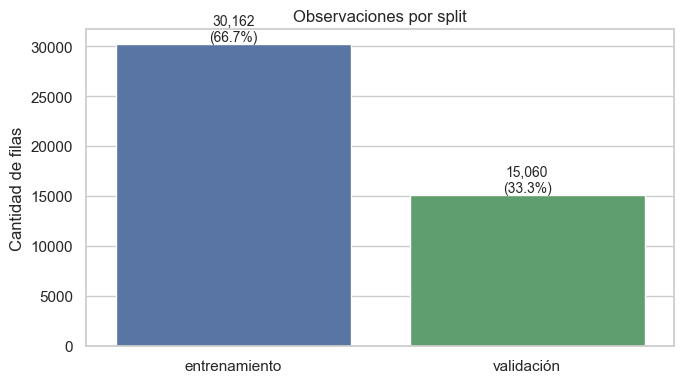

Total de observaciones: 45,222


In [131]:
# 1.1 y 1.2 — Resumen numérico y tamaño de los splits
COLUMNAS_NUMERICAS = ["age", "capital-gain", "capital-loss", "hours-per-week"]

percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

print("=== 1.1 — Estadísticas descriptivas (train) ===")
display(df_entrenamiento[COLUMNAS_NUMERICAS].describe(percentiles=percentiles).T)

n_entrenamiento, n_validacion = len(df_entrenamiento), len(df_validacion)
n_total = n_entrenamiento + n_validacion

df_particiones = pd.DataFrame(
    {
        "particion": ["entrenamiento", "validación"],
        "filas": [n_entrenamiento, n_validacion],
        "proporcion": [n_entrenamiento / n_total, n_validacion / n_total],
    }
)

print("\n=== 1.2 — Filas por split ===")

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=df_particiones,
    x="particion",
    y="filas",
    order=["entrenamiento", "validación"],
    hue="particion",
    legend=False,
    palette={"entrenamiento": "#4C72B0", "validación": "#55A868"},
    ax=ax,
)
ax.set_title("Observaciones por split")
ax.set_xlabel("")
ax.set_ylabel("Cantidad de filas")

for barra, (_, fila) in zip(ax.patches, df_particiones.iterrows()):
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(fila['filas']):,}\n({fila['proporcion'] * 100:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

print(f"Total de observaciones: {n_total:,}")

#### Variable objetivo (`income`)

Clasificación binaria: `<=50K` vs `>50K`. En el código siguiente se resume el **conteo** en train y un gráfico de barras.

**Observaciones del análisis (train):**

- **Desbalance de clases:** la mayoría de los registros pertenece a `<=50K` (~75%) y la clase minoritaria `>50K` ronda el **25%**. No es un desbalance extremo (p. ej. 99:1), pero sí **moderado** y suficiente para que un modelo que prediga siempre la mayoría obtenga ~75% de accuracy sin aprender patrones útiles.
- **Implicancias para el modelado:** conviene priorizar métricas como **F1 macro**, **recall** de la clase `>50K` y la **matriz de confusión**, además de la accuracy. Si el desempeño en la minoritaria es bajo, evaluar **class weights**, umbral de decisión o técnicas de balanceo según lo visto en el curso.
- **Calidad del target:** solo dos etiquetas bien definidas, sin valores faltantes en este dataset y sin ambigüedad de codificación aparente en train.
- **Consistencia train / val:** en val la proporción de `>50K` es muy similar (~24,6%), por lo que no se observa un desbalance muy distinto entre splits en esta primera revisión.

=== 1.3 — Target income (train) ===


,clase,conteo,porcentaje
0,<=50K,22654,75.107751
1,>50K,7508,24.892249



La clase '>50K' representa el 24.9% del train: hay desbalance de clases (mayoría '<=50K'). Conviene reportar F1 macro y no confiar solo en accuracy.


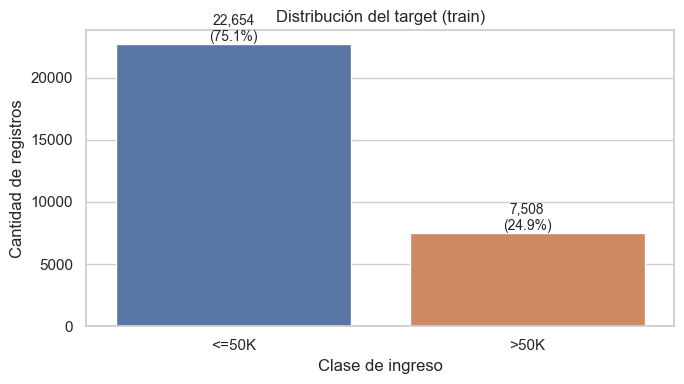

In [ ]:
# 1.3 — Distribución del target (income, train)
ORDEN_CLASES_OBJETIVO = ["<=50K", ">50K"]

df_objetivo = (
    df_entrenamiento[COLUMNA_OBJETIVO]
    .value_counts()
    .reindex(ORDEN_CLASES_OBJETIVO)
    .rename_axis("clase")
    .reset_index(name="conteo")
)
df_objetivo["porcentaje"] = 100 * df_objetivo["conteo"] / df_objetivo["conteo"].sum()

print(f"=== 1.3 — Target {COLUMNA_OBJETIVO} (train) ===")
display(df_objetivo)

pct_clase_minoritaria = df_objetivo.loc[df_objetivo["clase"] == ">50K", "porcentaje"].iloc[0]
print(
    f"\nLa clase '>50K' representa el {pct_clase_minoritaria:.1f}% del train: "
    "hay desbalance de clases (mayoría '<=50K'). "
    "Conviene reportar F1 macro y no confiar solo en accuracy."
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=df_objetivo,
    x="clase",
    y="conteo",
    order=ORDEN_CLASES_OBJETIVO,
    hue="clase",
    legend=False,
    palette={"<=50K": "#4C72B0", ">50K": "#DD8452"},
    ax=ax,
)
ax.set_title("Distribución del target (train)")
ax.set_xlabel("Clase de ingreso")
ax.set_ylabel("Cantidad de registros")

for barra, (_, fila) in zip(ax.patches, df_objetivo.iterrows()):
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(fila['conteo']):,}\n({fila['porcentaje']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

#### Valores extremos en variables numéricas

Se complementa el `describe()` de **1.1** con la proporción de **ceros** y **boxplots** de cada numérica frente a `income` (train).

**Análisis y observaciones:**

- **`age` y `hours-per-week`:** sin registros en cero. Rangos acotados (edad hasta ~90 años; horas hasta ~99/semana; p99 ≈ 72 y 80 respectivamente). En los boxplots se ven distribuciones similares entre `<=50K` y `>50K`, con pocos outliers extremos.
- **`capital-gain`:** **~91,6%** de los registros valen **0** (“sin ganancia de capital”). El máximo (**99,999**) está muy por encima del percentil 99 (~15,024), señal de **cola larga** y valores atípicos. La mediana de `>50K` supera claramente a la de `<=50K` en el boxplot.
- **`capital-loss`:** **~95,3%** en cero. También hay **cola positiva** (máx. 4,356 vs p99 ≈ 1,980). Patrón parecido a `capital-gain`, con más concentración en cero.
- **Implicancias para el preprocesado:** para `capital-gain` y `capital-loss` conviene separar “sin movimiento” (0) de montos positivos y, sobre los positivos, evaluar **log1p** o escalado robusto; no tratarlas como variables gaussianas sin transformar.
- **Relación con el target:** las diferencias por clase en `capital-gain` son más marcadas que en `age` u `hours-per-week`, lo que sugiere mayor señal predictiva (sin implicar causalidad).

=== 1.4 — Percentiles y proporción de ceros (train) ===


,% registros en cero
age,0.000000
capital-gain,91.585439
capital-loss,95.268881
hours-per-week,0.000000


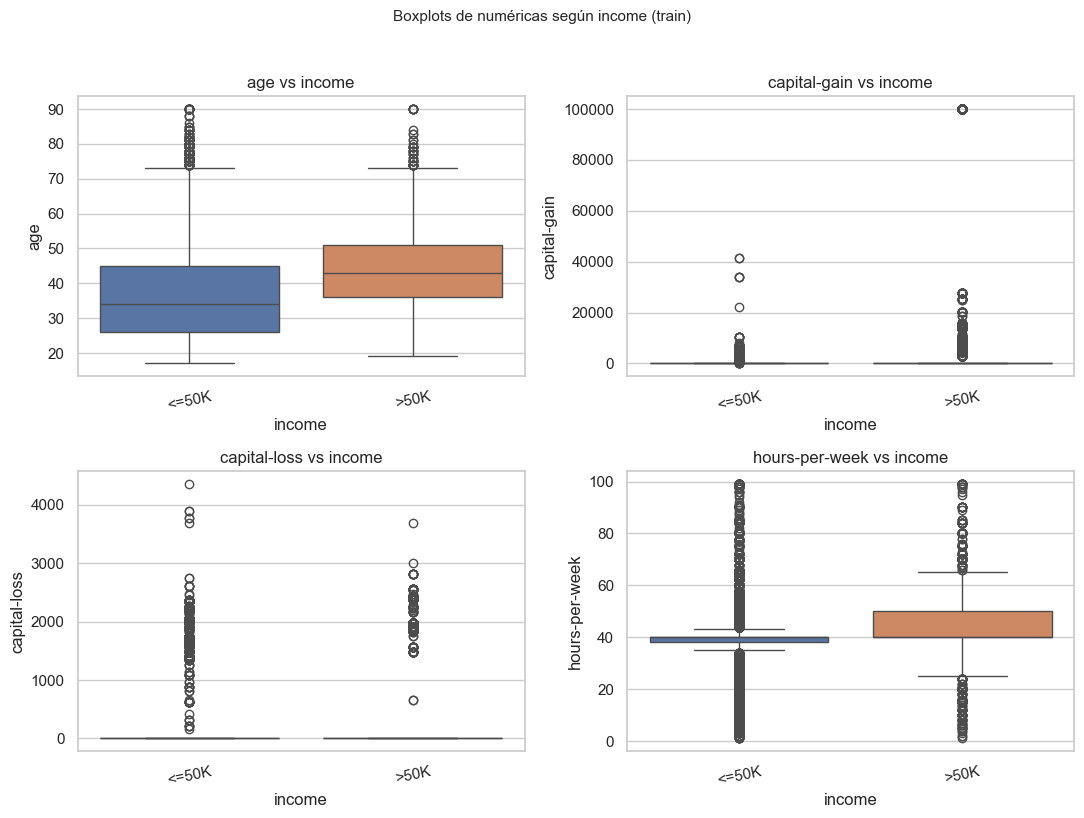

In [ ]:
# 1.4 — Valores extremos en variables numéricas (train)
print("=== 1.4 — Percentiles y proporción de ceros (train) ===")

proporcion_ceros = (
    (df_entrenamiento[COLUMNAS_NUMERICAS] == 0)
    .mean()
    .mul(100)
    .rename("% registros en cero")
    .to_frame()
)
display(proporcion_ceros)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

for ax, columna in zip(axes, COLUMNAS_NUMERICAS):
    sns.boxplot(
        data=df_entrenamiento,
        x=COLUMNA_OBJETIVO,
        y=col,
        order=ORDEN_CLASES_OBJETIVO,
        palette={"<=50K": "#4C72B0", ">50K": "#DD8452"},
        ax=ax,
    )
    ax.set_title(f"{columna} vs {COLUMNA_OBJETIVO}")
    ax.tick_params(axis="x", rotation=12)

fig.suptitle("Boxplots de numéricas según income (train)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 1.5 — Cardinalidad por variable (train)
UMBRAL_ALTA_CARDINALIDAD = 10

columnas_categoricas = df_entrenamiento[columnas_predictoras].select_dtypes(include=["object", "string"]).columns.tolist()
conjunto_categoricas = set(columnas_categoricas)

filas_cardinalidad = []
for columna in columnas_predictoras:
    n_unicos = df_entrenamiento[columna].nunique()
    es_categorica = col in conjunto_categoricas
    filas_cardinalidad.append(
        {
            "variable": columna,
            "tipo": "categórica" if es_categorica else "numérica",
            "valores_unicos": n_unicos,
            "alta_cardinalidad": es_categorica and n_unicos >= UMBRAL_ALTA_CARDINALIDAD,
        }
    )

df_cardinalidad = (
    pd.DataFrame(filas_cardinalidad)
    .sort_values(["tipo", "valores_unicos"], ascending=[True, False])
    .reset_index(drop=True)
)

columnas_alta_cardinalidad = df_cardinalidad.loc[
    df_cardinalidad["alta_cardinalidad"], "variable"
].tolist()

from IPython.display import HTML, display

df_alta_cardinalidad = df_cardinalidad.loc[
    df_cardinalidad["alta_cardinalidad"], ["variable", "tipo", "valores_unicos"]
].reset_index(drop=True)

print(
    f"=== 1.5 — Cardinalidad por variable "
    f"(alta cardinalidad en categóricas: ≥ {UMBRAL_ALTA_CARDINALIDAD} valores únicos) ==="
)

html_tabla_alta = (
    df_alta_cardinalidad.to_html(index=False, border=0)
    if len(df_alta_cardinalidad)
    else "<p style='margin:0'><em>ninguna</em></p>"
)

display(
    HTML(
        f"""
<div style="display:flex; flex-wrap:wrap; gap:2.5rem; align-items:flex-start;">
  <div>
    <p style="font-weight:600; margin:0 0 0.5rem 0;">Todas las variables</p>
    {df_cardinalidad.to_html(index=False, border=0)}
  </div>
  <div>
    <p style="font-weight:600; margin:0 0 0.5rem 0;">
      Alta cardinalidad ({len(columnas_alta_cardinalidad)})
    </p>
    {html_tabla_alta}
  </div>
</div>
"""
    )
)

=== 1.5 — Cardinalidad por variable (alta cardinalidad en categóricas: ≥ 10 valores únicos) ===


variable,tipo,valores_unicos,alta_cardinalidad
skill-profile,categórica,80,True
native-country,categórica,41,True
education,categórica,16,True
occupation,categórica,14,True
workclass,categórica,7,False
marital-status,categórica,7,False
relationship,categórica,6,False
race,categórica,5,False
sex,categórica,2,False
capital-gain,numérica,118,False


#### Distribución de variables de alta cardinalidad

| Variable | Valores únicos | Gráfico elegido | Motivo |
|----------|----------------|-----------------|--------|
| `education` | 16 | Barras horizontales en **orden educativo** | Nivel con orden natural; conviene ver el “escalón” de formación, no solo la frecuencia. |
| `occupation` | 14 | Barras horizontales por **frecuencia** (todas las categorías) | Variable nominal con pocas clases y distribución relativamente pareja. |
| `native-country` | 41 | **Top-12** + categoría *Otros* | Fuerte dominancia de `United-States` (~91%); el resto son cola larga de países minoritarios. |
| `skill-profile` | 80 | **Top-15** + *Otros* | Muchas habilidades con baja frecuencia; mostrar todas las barras sería ilegible. |

=== 1.6 — Distribución de variables de alta cardinalidad (train) ===



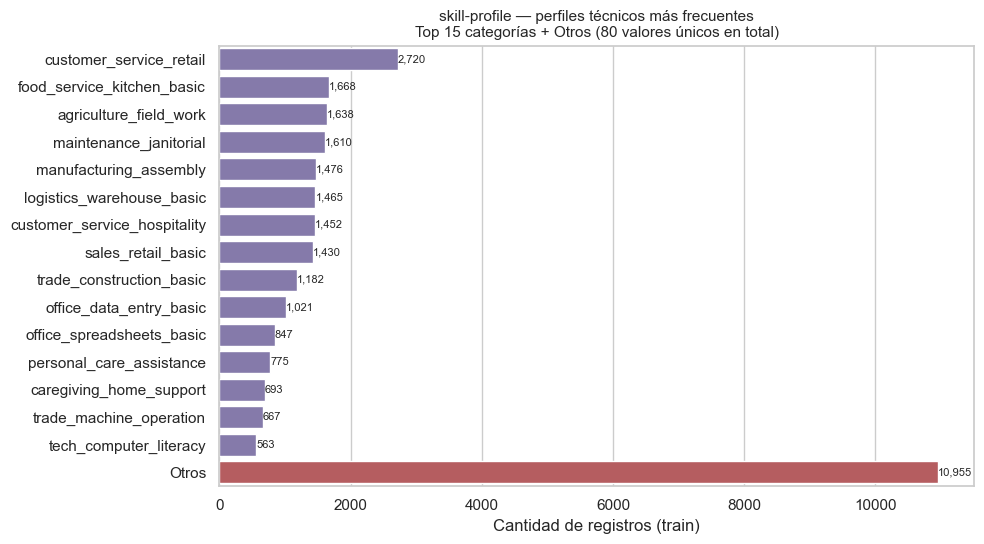

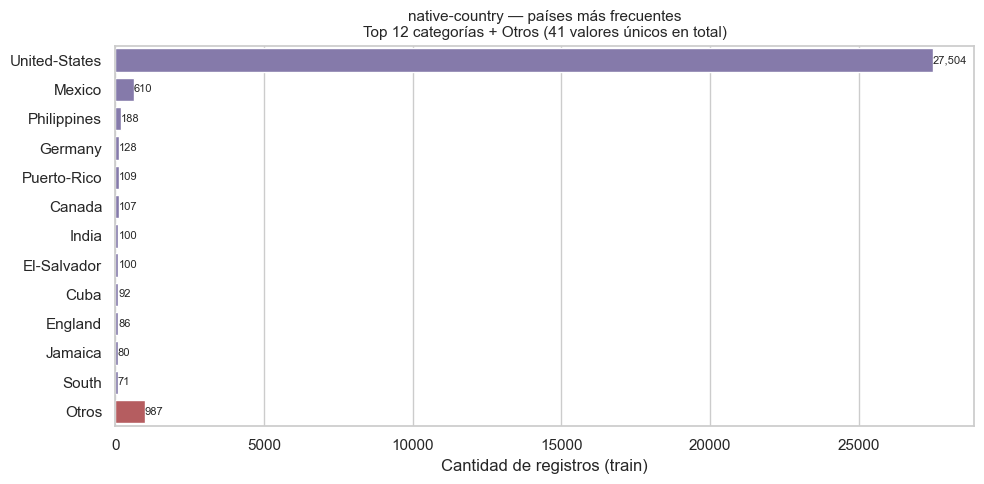

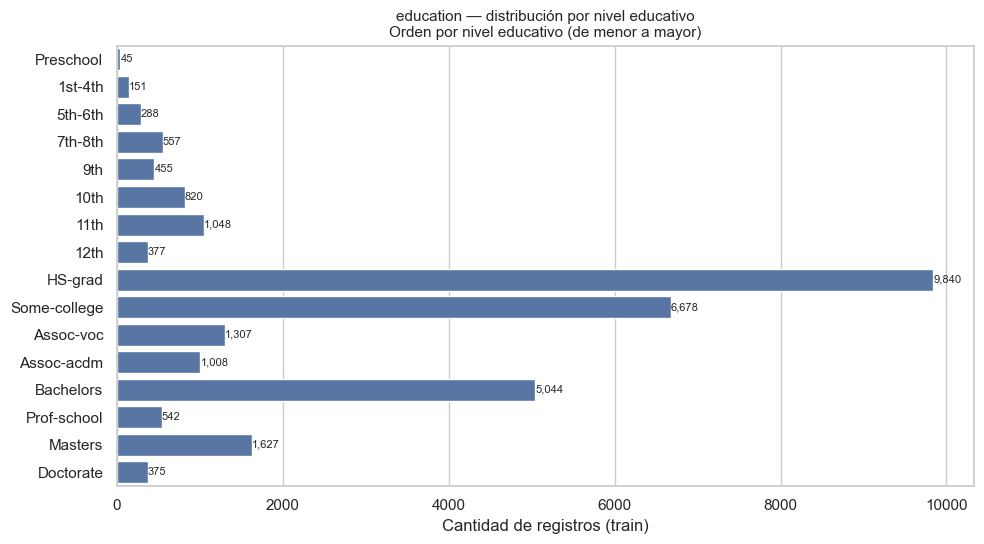

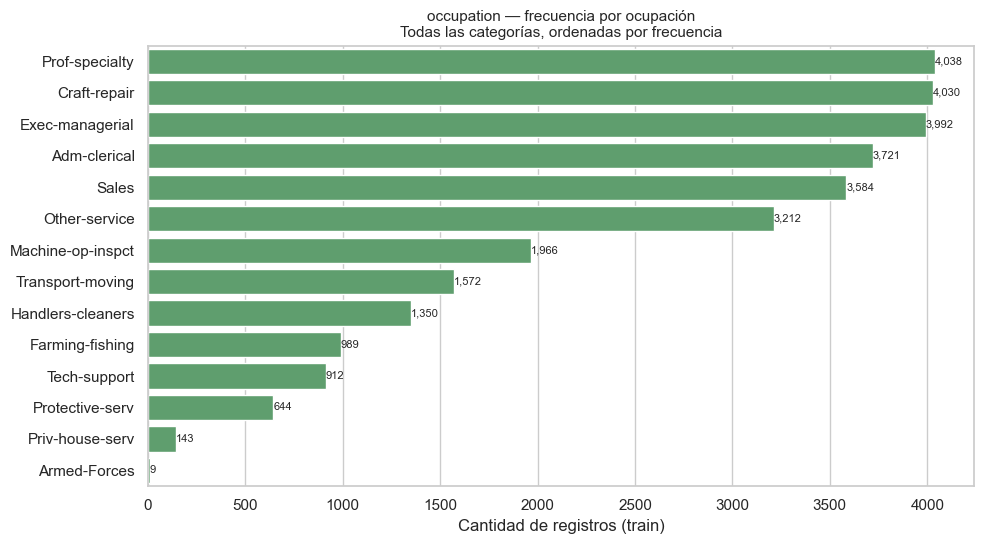

In [ ]:
# 1.6 — Distribución de frecuencias (variables de alta cardinalidad, train)

ORDEN_EDUCACION = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Prof-school",
    "Masters",
    "Doctorate",
]


def etiquetar_barras(ax, horizontal: bool = True) -> None:
    for parche in ax.patches:
        tamano = parche.get_width() if horizontal else parche.get_height()
        if tamano <= 0:
            continue
        etiqueta = f"{int(tamano):,}"
        if horizontal:
            ax.text(tamano, parche.get_y() + parche.get_height() / 2, etiqueta, va="center", ha="left", fontsize=8)
        else:
            ax.text(parche.get_x() + parche.get_width() / 2, tamano, etiqueta, ha="center", va="bottom", fontsize=8)


def graficar_distribucion_categorica(
    serie: pd.Series,
    *,
    titulo: str,
    estilo: str,
    n_superior: int | None = None,
    orden_categorias: list[str] | None = None,
) -> None:
    conteos = serie.value_counts()

    if estilo == "ordinal":
        orden = [c for c in (orden_categorias or []) if c in conteos.index]
        df_grafico = conteos.reindex(orden).dropna().reset_index()
        df_grafico.columns = ["categoria", "conteo"]
        altura_figura = max(5, 0.35 * len(df_grafico))
        fig, ax = plt.subplots(figsize=(10, altura_figura))
        sns.barplot(data=df_grafico, y="categoria", x="conteo", order=orden, color="#4C72B0", ax=ax)
        subtitulo = "Orden por nivel educativo (de menor a mayor)"

    elif estilo == "frecuencia_total":
        df_grafico = conteos.reset_index()
        df_grafico.columns = ["categoria", "conteo"]
        altura_figura = max(5, 0.4 * len(df_grafico))
        fig, ax = plt.subplots(figsize=(10, altura_figura))
        sns.barplot(data=df_grafico, y="categoria", x="conteo", color="#55A868", ax=ax)
        subtitulo = "Todas las categorías, ordenadas por frecuencia"

    elif estilo == "n_superior":
        filas_superiores = conteos.head(n_superior)
        otros = conteos.iloc[n_superior:].sum()
        filas = [{"categoria": indice, "conteo": valor} for indice, valor in filas_superiores.items()]
        if otros > 0:
            filas.append({"categoria": "Otros", "conteo": otros})
        df_grafico = pd.DataFrame(filas)
        fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(df_grafico))))
        paleta = ["#C44E52" if categoria == "Otros" else "#8172B2" for categoria in df_grafico["categoria"]]
        sns.barplot(data=df_grafico, y="categoria", x="conteo", palette=paleta, ax=ax)
        subtitulo = f"Top {n_superior} categorías + Otros ({conteos.shape[0]} valores únicos en total)"
    else:
        raise ValueError(f"Estilo de gráfico no soportado: {estilo}")

    ax.set_title(f"{titulo}\n{subtitulo}", fontsize=11)
    ax.set_xlabel("Cantidad de registros (train)")
    ax.set_ylabel("")
    etiquetar_barras(ax, horizontal=True)
    plt.tight_layout()
    plt.show()


if not columnas_alta_cardinalidad:
    print("No hay variables de alta cardinalidad para graficar.")
else:
    especificaciones_grafico = {
        "education": {
            "titulo": "education — distribución por nivel educativo",
            "estilo": "ordinal",
            "orden_categorias": ORDEN_EDUCACION,
        },
        "occupation": {
            "titulo": "occupation — frecuencia por ocupación",
            "estilo": "frecuencia_total",
        },
        "native-country": {
            "titulo": "native-country — países más frecuentes",
            "estilo": "top_n",
            "n_superior": 12,
        },
        "skill-profile": {
            "titulo": "skill-profile — perfiles técnicos más frecuentes",
            "estilo": "top_n",
            "n_superior": 15,
        },
    }

    print("=== 1.6 — Distribución de variables de alta cardinalidad (train) ===\n")
    for columna in columnas_alta_cardinalidad:
        especificacion = especificaciones_grafico.get(columna)
        if especificacion is None:
            print(f"Sin especificación de gráfico para '{columna}' — se omite.")
            continue
        graficar_distribucion_categorica(df_entrenamiento[columna], **especificacion)

#### Distribución de variables categóricas de baja cardinalidad

Variables categóricas con **menos de 10** valores únicos (criterio del TP).

| Variable | Valores únicos | Gráfico elegido | Motivo |
|----------|----------------|-----------------|--------|
| `workclass`, `marital-status`, `relationship`, `race` | 5–7 | **Barras verticales** en grilla **2×2** | Pocas categorías; caben en un panel compacto comparando frecuencias. |
| `sex` | 2 | **Gráfico de torta** | Solo dos clases; la proporción se lee de un vistazo. |

=== 1.6b — Distribución de variables categóricas de baja cardinalidad (5 variables, train) ===



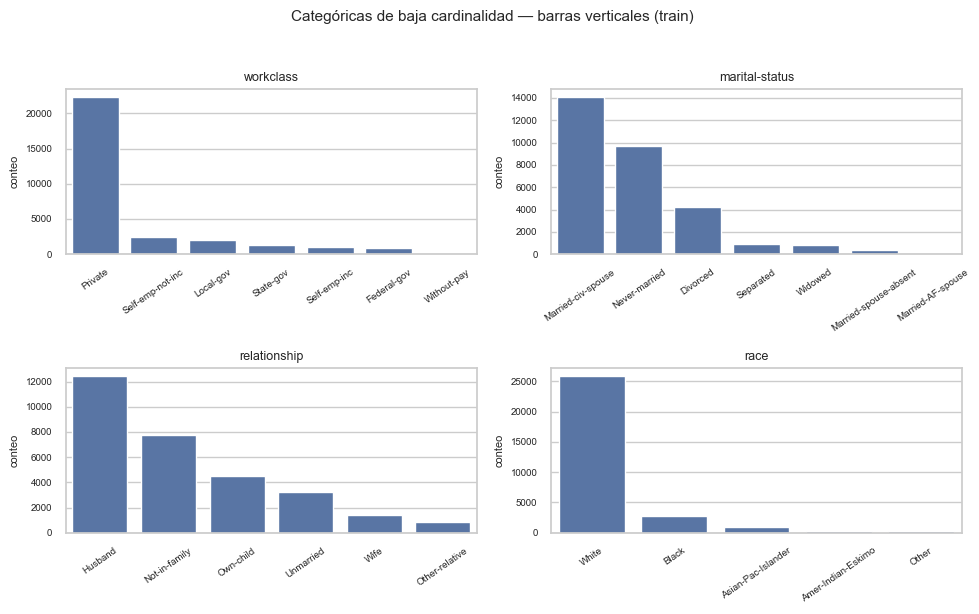

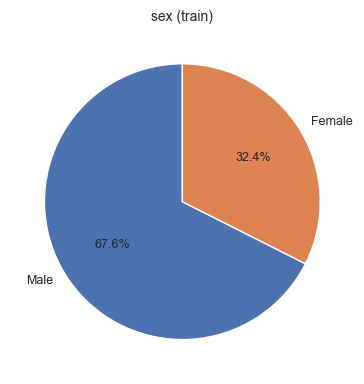

In [ ]:
# 1.6b — Distribución de frecuencias (categóricas de baja cardinalidad, train)

columnas_baja_cardinalidad = df_cardinalidad.loc[
    (df_cardinalidad["tipo"] == "categórica") & (~df_cardinalidad["alta_cardinalidad"]),
    "variable",
].tolist()

columnas_grafico_barras_baja = ["workclass", "marital-status", "relationship", "race"]
titulos_baja_cardinalidad = {
    "workclass": "workclass",
    "marital-status": "marital-status",
    "relationship": "relationship",
    "race": "race",
}

print(
    "=== 1.6b — Distribución de variables categóricas de baja cardinalidad "
    f"({len(columnas_baja_cardinalidad)} variables, train) ===\n"
)

if not columnas_baja_cardinalidad:
    print("No hay variables categóricas de baja cardinalidad para graficar.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.ravel()

    for ax, columna in zip(axes, columnas_grafico_barras_baja):
        df_grafico = (
            df_entrenamiento[columna]
            .value_counts()
            .sort_values(ascending=False)
            .reset_index()
        )
        df_grafico.columns = ["categoria", "conteo"]
        sns.barplot(data=df_grafico, x="categoria", y="conteo", color="#4C72B0", ax=ax)
        ax.set_title(titulos_baja_cardinalidad[columna], fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("conteo", fontsize=8)
        ax.tick_params(axis="x", rotation=35, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

    fig.suptitle(
        "Categóricas de baja cardinalidad — barras verticales (train)",
        fontsize=11,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    if "sex" in columnas_baja_cardinalidad:
        conteos_sexo = df_entrenamiento["sex"].value_counts()
        fig, ax = plt.subplots(figsize=(4.5, 4))
        ax.pie(
            conteos_sexo,
            labels=conteos_sexo.index,
            autopct="%1.1f%%",
            startangle=90,
            colors=["#4C72B0", "#DD8452"],
            textprops={"fontsize": 9},
        )
        ax.set_title("sex (train)", fontsize=10)
        plt.tight_layout()
        plt.show()

#### Distribución de variables numéricas

| Variable | Gráfico elegido | Motivo |
|----------|-----------------|--------|
| `age` | **Histograma + KDE** | Edad sin ceros artificiales; distribución unimodal y casi simétrica. |
| `hours-per-week` | **Histograma + KDE** | Horas trabajadas con dispersión continua y cola moderada. |
| `capital-gain` | **Dos paneles**: torta *sin ganancia (0)* vs *con ganancia* + histograma **log1p** de valores > 0 | ~92% en cero; la cola positiva es muy asimétrica. |
| `capital-loss` | Igual que `capital-gain` | ~95% en cero; misma estructura de inflación en cero y cola larga. |

=== 1.7 — Distribución de variables numéricas (train) ===



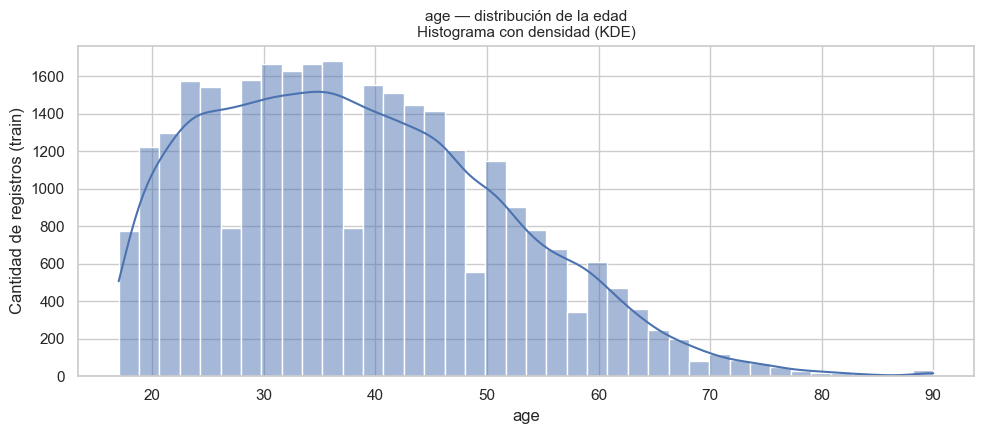

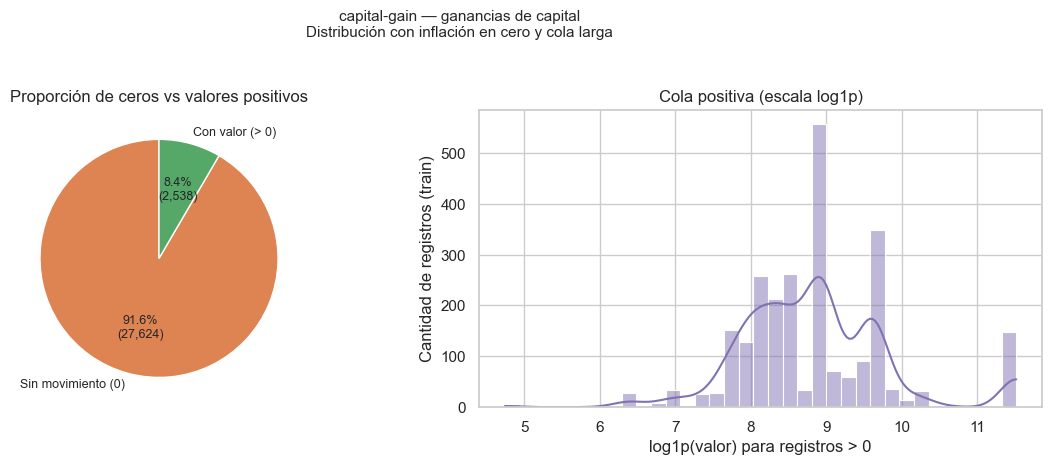

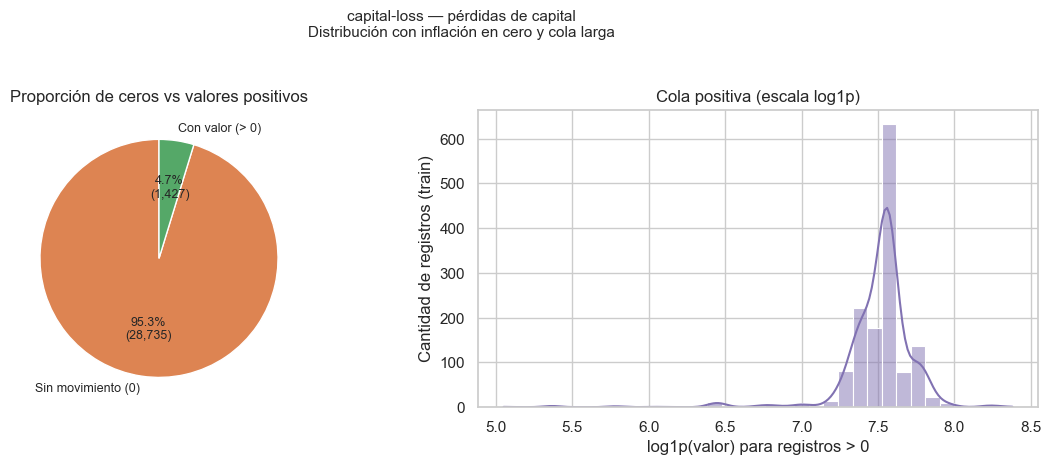

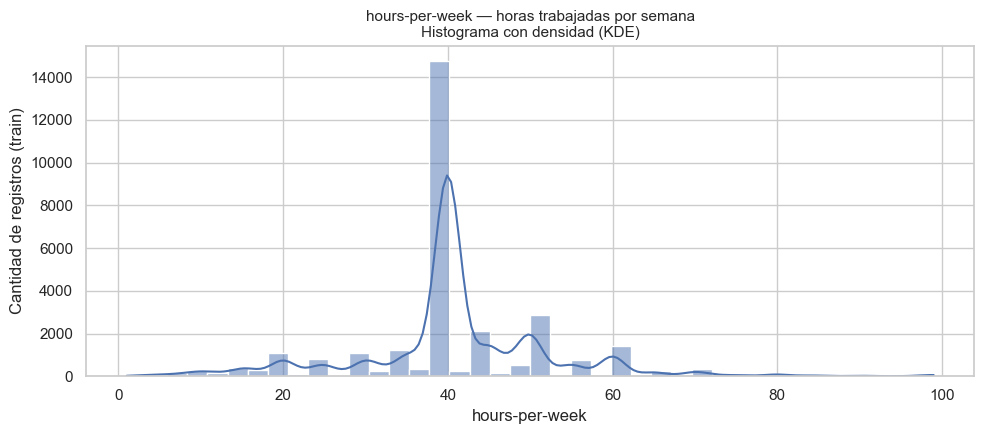

In [ ]:
# 1.7 — Distribución de variables numéricas (train)


def graficar_distribucion_numerica(serie: pd.Series, *, titulo: str, estilo: str) -> None:
    if estilo == "histograma_kde":
        fig, ax = plt.subplots(figsize=(10, 4.5))
        sns.histplot(serie, bins=40, kde=True, color="#4C72B0", ax=ax)
        ax.set_xlabel(titulo.split("—")[0].strip())
        ax.set_ylabel("Cantidad de registros (train)")
        ax.set_title(f"{titulo}\nHistograma con densidad (KDE)", fontsize=11)
        plt.tight_layout()
        plt.show()
        return

    if estilo == "inflacion_ceros":
        conteo_ceros = (serie == 0).sum()
        valores_positivos = serie[serie > 0]
        conteo_positivos = len(valores_positivos)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

        etiquetas_torta = ["Sin movimiento (0)", "Con valor (> 0)"]
        tamanos_torta = [conteo_ceros, conteo_positivos]
        colores_torta = ["#DD8452", "#55A868"]

        axes[0].pie(
            tamanos_torta,
            labels=etiquetas_torta,
            autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct * len(serie) / 100)):,})",
            startangle=90,
            colors=colores_torta,
            textprops={"fontsize": 9},
        )
        axes[0].set_title("Proporción de ceros vs valores positivos")

        if conteo_positivos > 0:
            sns.histplot(np.log1p(valores_positivos), bins=35, kde=True, color="#8172B2", ax=axes[1])
            axes[1].set_xlabel("log1p(valor) para registros > 0")
        else:
            axes[1].text(0.5, 0.5, "Sin valores > 0", ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("Cola positiva (escala log1p)")
        axes[1].set_ylabel("Cantidad de registros (train)")

        fig.suptitle(
            f"{titulo}\nDistribución con inflación en cero y cola larga",
            fontsize=11,
            y=1.03,
        )
        plt.tight_layout()
        plt.show()
        return

    raise ValueError(f"Estilo de gráfico no soportado: {estilo}")


especificaciones_grafico_numerico = {
    "age": {
        "titulo": "age — distribución de la edad",
        "estilo": "histograma_kde",
    },
    "hours-per-week": {
        "titulo": "hours-per-week — horas trabajadas por semana",
        "estilo": "histograma_kde",
    },
    "capital-gain": {
        "titulo": "capital-gain — ganancias de capital",
        "estilo": "inflacion_ceros",
    },
    "capital-loss": {
        "titulo": "capital-loss — pérdidas de capital",
        "estilo": "inflacion_ceros",
    },
}

print("=== 1.7 — Distribución de variables numéricas (train) ===\n")
for columna in COLUMNAS_NUMERICAS:
    especificacion = especificaciones_grafico_numerico[columna]
    graficar_distribucion_numerica(df_entrenamiento[columna], **especificacion)

### Fase 2 — EDA por tipo de variable

#### Variables numéricas — ítems 2.1 y 2.2 (cubiertos en Fase 1)

Los requisitos **2.1** y **2.2** ya están resueltos en el notebook; no se duplican gráficos aquí:

| Ítem | Contenido | Dónde en el notebook |
|------|-----------|----------------------|
| **2.1** | Histogramas / KDE de `age`, `capital-gain`, `capital-loss`, `hours-per-week` (train) | Celda **1.7** |
| **2.2** | Boxplots de numéricas vs `income` | Celda **1.4** (con observaciones en markdown) |

*Nota:* la comparación train vs val (target, numéricas y categóricas clave) está en el ítem **2.9**.

#### 2.3 — Correlación entre variables numéricas (train)

**¿Para qué la hacemos?**

La matriz de correlación permite ver si las variables numéricas comparten variación lineal (Pearson) o de rangos (Spearman). Eso ayuda a:

- Detectar **redundancia** entre features (multicolinealidad leve o fuerte).
- Complementar boxplots e histogramas: dos variables pueden parecer distintas marginalmente y aun así moverse juntas.
- Anticipar el **preprocesado**: si hubiera correlaciones muy altas, podría evaluarse eliminar una variable o usar transformaciones que no amplifiquen dependencias artificiales.

En este dataset, `capital-gain` y `capital-loss` tienen muchos ceros; conviene comparar **Pearson** y **Spearman** porque la relación monótona no tiene por qué ser lineal.

**Conclusión breve (train):**

- Todas las correlaciones son **débiles** (en valor absoluto, por debajo de ~0,16): no hay pares numéricos fuertemente colineales.
- La asociación más notable es **`age` ↔ `hours-per-week`** (r ≈ 0,10 Pearson; ρ ≈ 0,16 Spearman): a mayor edad, algo más de horas trabajadas en promedio, pero la relación es leve.
- **`capital-gain` ↔ `capital-loss`** muestran correlación cercana a **cero** (ligeramente negativa), coherente con que muchos registros tienen 0 en ambas y las colas positivas no van siempre de la mano.
- **Implicancia:** las cuatro numéricas pueden aportar información **relativamente complementaria** al modelo; no surge una redundancia que obligue a descartar una feature solo por correlación. Las transformaciones de `capital-*` siguen siendo prioritarias por la inflación en cero, no por correlación entre features.

=== 2.3 — Correlación entre numéricas (train) ===



,age,capital-gain,capital-loss,hours-per-week
age,1.000,0.080,0.060,0.102
capital-gain,0.080,1.000,-0.032,0.080
capital-loss,0.060,-0.032,1.000,0.052
hours-per-week,0.102,0.080,0.052,1.000


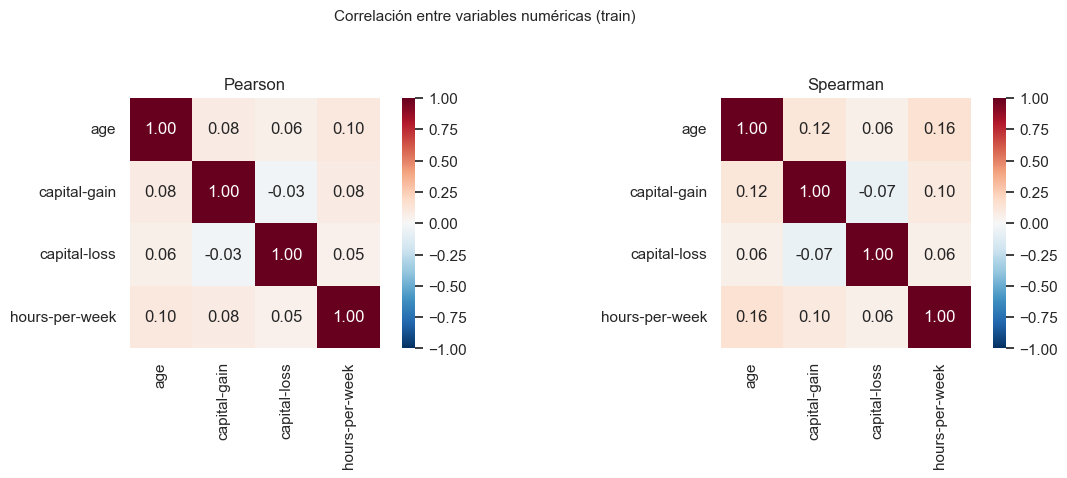

In [ ]:
# 2.3 — Matrices de correlación entre numéricas (train)
df_numericas = df_entrenamiento[COLUMNAS_NUMERICAS]

correlacion_pearson = df_numericas.corr(method="pearson")
correlacion_spearman = df_numericas.corr(method="spearman")

print("=== 2.3 — Correlación entre numéricas (train) ===\n")
display(correlacion_pearson.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(
    correlacion_pearson,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Pearson")

sns.heatmap(
    correlacion_spearman,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1],
)
axes[1].set_title("Spearman")

fig.suptitle("Correlación entre variables numéricas (train)", fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

#### 2.4 — Inventario de categorías (train)

Para cada variable categórica se listan **todas** las categorías observadas en train, ordenadas por **frecuencia decreciente**, con **conteo** y **porcentaje** sobre el total de filas de esa variable.

In [ ]:
# 2.4 — Valores únicos, conteo y porcentaje por categoría (train)


def tabla_frecuencia_categoria(serie: pd.Series) -> pd.DataFrame:
    tabla = (
        serie.value_counts()
        .rename_axis("categoria")
        .reset_index(name="conteo")
    )
    tabla["porcentaje"] = (100 * tabla["conteo"] / len(serie)).round(2)
    return tabla


print("=== 2.4 — Inventario de categorías (train) ===\n")

for columna in columnas_categoricas:
    n_unicos = df_entrenamiento[columna].nunique()
    print(f"--- {columna} ({n_unicos} categorías) ---")
    display(tabla_frecuencia_categoria(df_entrenamiento[columna]))

=== 2.4 — Inventario de categorías (train) ===

--- workclass (7 categorías) ---


,categoria,conteo,porcentaje
0,Private,22286,73.89
1,Self-emp-not-inc,2499,8.29
2,Local-gov,2067,6.85
3,State-gov,1279,4.24
4,Self-emp-inc,1074,3.56
5,Federal-gov,943,3.13
6,Without-pay,14,0.05


--- education (16 categorías) ---


,categoria,conteo,porcentaje
0,HS-grad,9840,32.62
1,Some-college,6678,22.14
2,Bachelors,5044,16.72
3,Masters,1627,5.39
4,Assoc-voc,1307,4.33
5,11th,1048,3.47
6,Assoc-acdm,1008,3.34
7,10th,820,2.72
8,7th-8th,557,1.85
9,Prof-school,542,1.80


--- marital-status (7 categorías) ---


...

,categoria,conteo,porcentaje
0,Male,20380,67.57
1,Female,9782,32.43


--- skill-profile (80 categorías) ---


,categoria,conteo,porcentaje
0,customer_service_retail,2720,9.02
1,food_service_kitchen_basic,1668,5.53
2,agriculture_field_work,1638,5.43
3,maintenance_janitorial,1610,5.34
4,manufacturing_assembly,1476,4.89
...,...,...,...
75,legal_office_support,48,0.16
76,education_research_methods,47,0.16
77,research_statistical_analysis,44,0.15
78,executive_decision_support,37,0.12


--- native-country (41 categorías) ---


,categoria,conteo,porcentaje
0,United-States,27504,91.19
1,Mexico,610,2.02
2,Philippines,188,0.62
3,Germany,128,0.42
4,Puerto-Rico,109,0.36
5,Canada,107,0.35
6,India,100,0.33
7,El-Salvador,100,0.33
8,Cuba,92,0.31
9,England,86,0.29


#### Variables categóricas — ítems 2.5 y 2.6 (cubiertos en Fase 1)

Los requisitos **2.5** y **2.6** ya están resueltos; no se duplican tablas ni gráficos aquí.

| Ítem | Contenido | Dónde en el notebook |
|------|-----------|----------------------|
| **2.5** | Cardinalidad (# valores únicos) y clasificación según criterio del TP | Celda **1.5** (`df_cardinalidad`, columna `alta_cardinalidad`) |
| **2.6** | Gráficos de frecuencia (barras / top-N + *Otros*) | Celdas **1.6** (alta cardinalidad) y **1.6b** (baja cardinalidad) |

**Clasificación de cardinalidad (criterio del TP, train):**

- **Alta (≥ 10 valores únicos):** `education`, `occupation`, `native-country`, `skill-profile`.
- **Baja (< 10):** `workclass`, `marital-status`, `relationship`, `race`, `sex`.

*Nota:* el enunciado define explícitamente solo el umbral de **alta cardinalidad** (≥ 10). No se usa una categoría intermedia “media”; las categóricas quedan en **baja** o **alta** respecto de ese umbral.

**Gráficos de frecuencia (2.6):**

- **Alta cardinalidad:** barras horizontales por variable; `native-country` y `skill-profile` con **top-N + Otros** (celda **1.6**).
- **Baja cardinalidad:** grilla 2×2 con barras verticales + torta para `sex` (celda **1.6b**).

#### 2.7 — Relación entre categóricas e `income` (train)

**¿Para qué lo hacemos?**

Mide si las categorías de cada variable se asocian de forma distinta con ingresos altos (`>50K`). Eso orienta la elección de codificación y qué features pueden ser más predictivas (sin implicar causalidad).

**Gráficos:** proporción de `>50K` por categoría (barras horizontales). En variables de alta cardinalidad se muestran las **top-12** categorías por frecuencia (el resto se omite en el gráfico, no en el análisis tabular resumido).

**Conclusión breve (train):**

- **`education` / `occupation`:** mayor tasa de `>50K` en niveles altos (`Prof-school`, `Doctorate`, `Masters`) y ocupaciones como `Exec-managerial` o `Prof-specialty`.
- **`sex`:** `Male` ~31% `>50K` vs `Female` ~11% — diferencia marcada en este dataset.
- **`marital-status`:** `Married-civ-spouse` ~46% `>50K`, muy por encima de `Never-married`, `Divorced` o `Widowed`.
- **`workclass`:** `Self-emp-inc` y empleos públicos (`Federal-gov`) muestran tasas más altas que `Private` o `Without-pay`.
- **`native-country` / `skill-profile`:** `United-States` concentra la mayoría de filas; en países/habilidades con poco soporte las tasas son inestables — conviene interpretar con cautela o agrupar categorías raras en el modelado.
- **Implicancia:** variables con fuerte separación por categoría (p. ej. `education`, `marital-status`, `sex`) son candidatas a distintas estrategias de encoding; el cruce refuerza por qué algunas irán a embedding u one-hot según cardinalidad y señal.

=== 2.7 — Relación categóricas vs income (train) ===

Top categorías por % >50K (conteo ≥ 50 en train):


,variable,categoria,conteo,pct_mayor_50k
0,workclass,Self-emp-inc,1074,55.9
1,workclass,Federal-gov,943,38.7
2,workclass,Local-gov,2067,29.5
3,education,Prof-school,542,74.9
4,education,Doctorate,375,74.7
5,education,Masters,1627,56.4
6,marital-status,Married-civ-spouse,14065,45.5
7,marital-status,Divorced,4214,10.7
8,marital-status,Widowed,827,9.7
9,occupation,Exec-managerial,3992,48.5


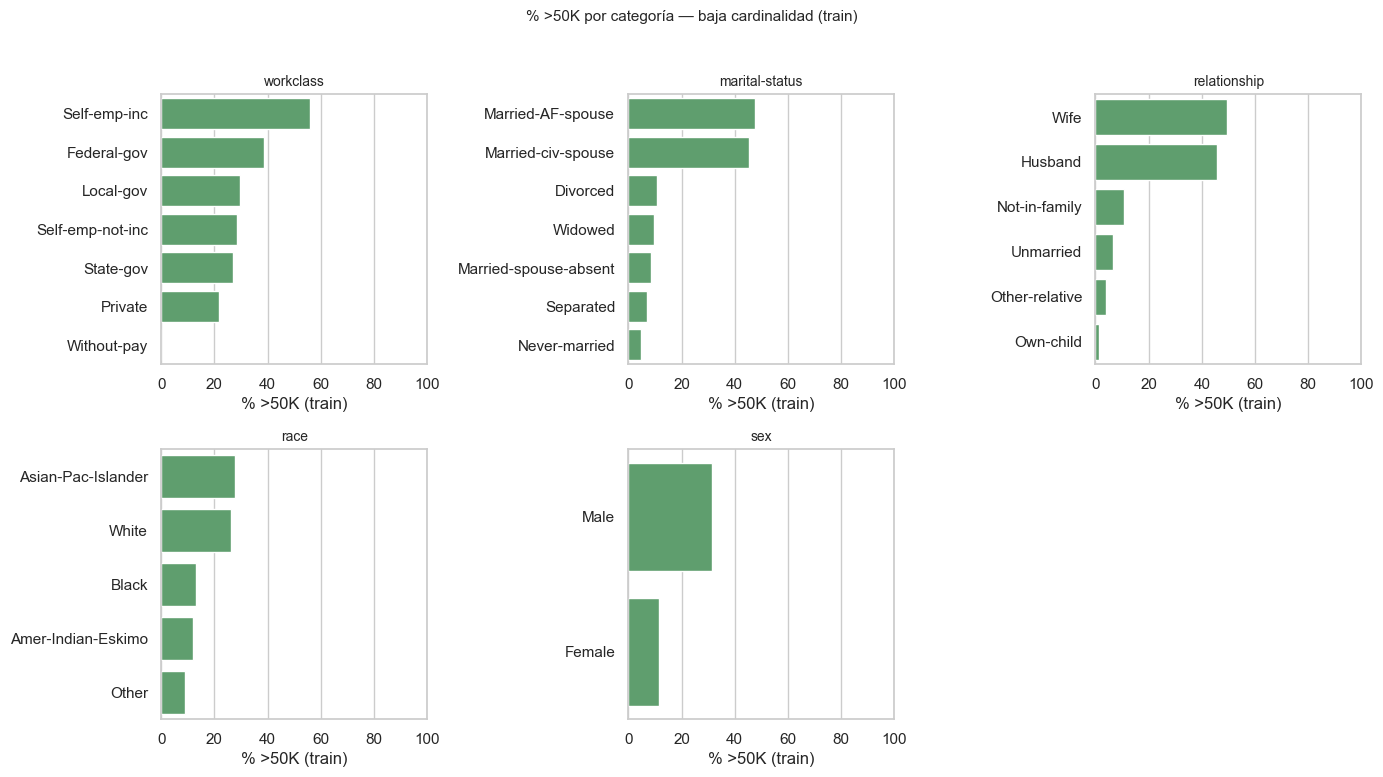

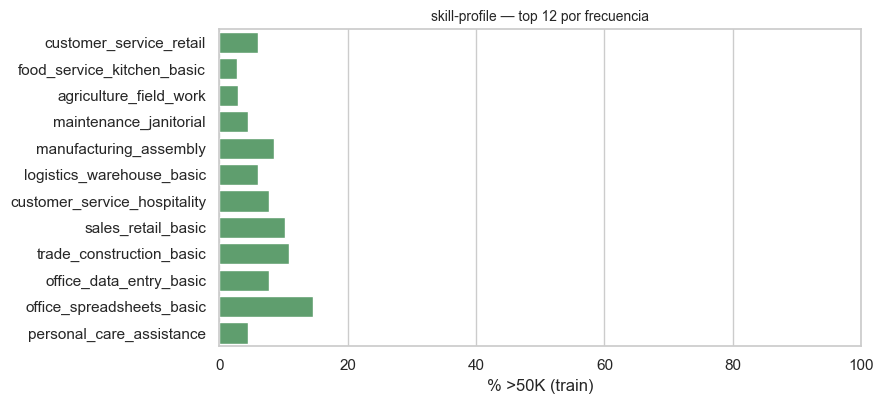

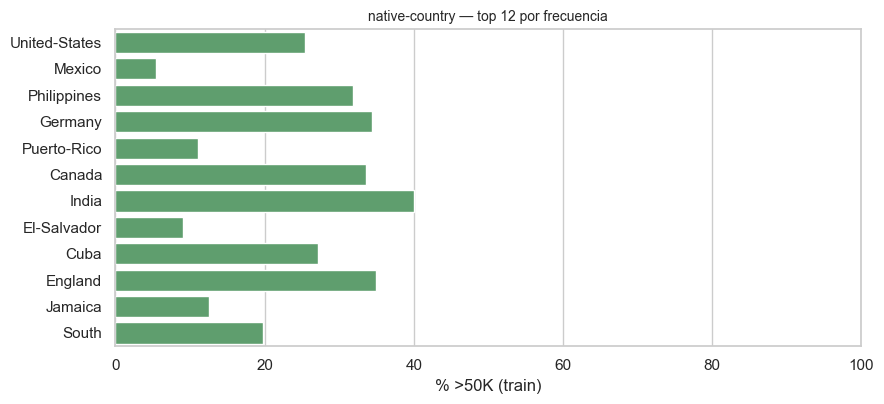

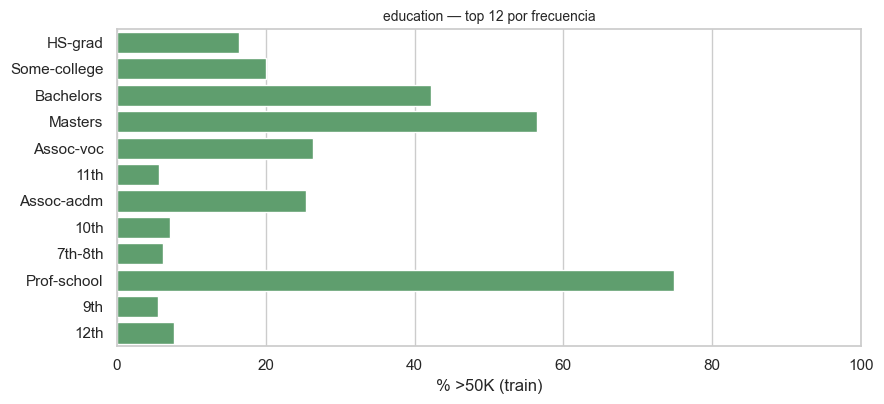

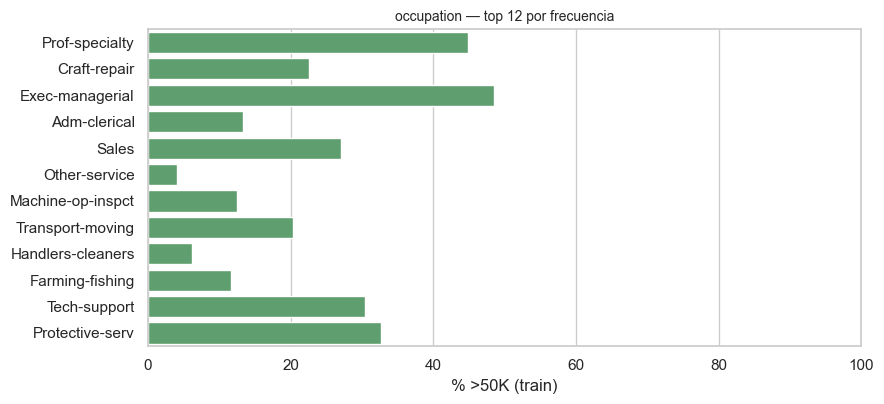

In [ ]:
# 2.7 — Proporción de >50K por categoría (train)
ETIQUETA_CLASE_MAYOR_50K = ">50K"
CONTEO_MINIMO_RESUMEN = 50
TOP_N_ALTA_CARDINALIDAD = 12

columnas_baja_cardinalidad = df_cardinalidad.loc[
    (df_cardinalidad["tipo"] == "categórica") & (~df_cardinalidad["alta_cardinalidad"]),
    "variable",
].tolist()
columnas_alta_cardinalidad_grafico = df_cardinalidad.loc[
    df_cardinalidad["alta_cardinalidad"], "variable"
].tolist()


def tasa_ingreso_por_categoria(df: pd.DataFrame, columna: str) -> pd.DataFrame:
    estadisticas = (
        df.groupby(columna, observed=True)
        .agg(
            conteo=(COLUMNA_OBJETIVO, "size"),
            pct_mayor_50k=(COLUMNA_OBJETIVO, lambda s: 100 * (s == ETIQUETA_CLASE_MAYOR_50K).mean()),
        )
        .reset_index()
        .rename(columns={columna: "categoria"})
    )
    return estadisticas.sort_values("pct_mayor_50k", ascending=False)


def graficar_tasa_ingreso(
    estadisticas: pd.DataFrame,
    *,
    titulo: str,
    n_superior: int | None = None,
    ax=None,
) -> None:
    df_grafico = estadisticas.head(n_superior) if n_superior else estadisticas
    figura_creada = ax is None
    if figura_creada:
        fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(df_grafico))))

    sns.barplot(
        data=df_grafico,
        y="categoria",
        x="pct_mayor_50k",
        color="#55A868",
        ax=ax,
    )
    ax.set_xlabel(f"% {ETIQUETA_CLASE_MAYOR_50K} (train)")
    ax.set_ylabel("")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlim(0, 100)

    if figura_creada:
        plt.tight_layout()
        plt.show()


print("=== 2.7 — Relación categóricas vs income (train) ===\n")

# Resumen: filas_superiores 3 categorías con mayor % >50K (conteo mínimo)
filas_resumen = []
for columna in columnas_categoricas:
    estadisticas = tasa_ingreso_por_categoria(df_entrenamiento, columna)
    primeras_tres = estadisticas[estadisticas["conteo"] >= CONTEO_MINIMO_RESUMEN].head(3)
    for _, fila in primeras_tres.iterrows():
        filas_resumen.append(
            {
                "variable": columna,
                "categoria": fila["categoria"],
                "conteo": int(fila["conteo"]),
                "pct_mayor_50k": round(fila["pct_mayor_50k"], 1),
            }
        )

print(f"Top categorías por % {ETIQUETA_CLASE_MAYOR_50K} (conteo ≥ {CONTEO_MINIMO_RESUMEN} en train):")
display(pd.DataFrame(filas_resumen))

# Baja cardinalidad: grilla 2×3
n_baja = len(columnas_baja_cardinalidad)
n_columnas = 3
n_filas = (n_baja + n_columnas - 1) // n_columnas
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.8 * n_filas))
axes = axes.ravel()

for ax, columna in zip(axes, columnas_baja_cardinalidad):
    estadisticas = tasa_ingreso_por_categoria(df_entrenamiento, columna)
    graficar_tasa_ingreso(estadisticas, titulo=columnaumna, ax=ax)

for ax in axes[len(columnas_baja_cardinalidad) :]:
    ax.axis("off")

fig.suptitle(
    f"% {ETIQUETA_CLASE_MAYOR_50K} por categoría — baja cardinalidad (train)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

# Alta cardinalidad: una figura por variable (filas_superiores-N por frecuencia)
for columna in columnas_alta_cardinalidad_grafico:
    orden_frecuencia = df_entrenamiento[columna].value_counts().head(TOP_N_ALTA_CARDINALIDAD).index
    estadisticas = tasa_ingreso_por_categoria(df_entrenamiento, columna)
    estadisticas_top = estadisticas[estadisticas["categoria"].isin(orden_frecuencia)].copy()
    estadisticas_top["categoria"] = pd.Categorical(
        estadisticas_top["categoria"], categorias=list(orden_frecuencia), ordered=True
    )
    estadisticas_top = estadisticas_top.sort_values("categoria")
    graficar_tasa_ingreso(
        estadisticas_top,
        titulo=f"{columna} — top {TOP_N_ALTA_CARDINALIDAD} por frecuencia",
    )

#### 2.8 — Categorías poco frecuentes y consistencia train / val

**¿Para qué lo hacemos?**

Las categorías con **pocos ejemplos en train** estiman mal los patrones (y los embeddings). Las categorías que aparecen **solo en val** (no vistas en entrenamiento) obligan a una política explícita en inferencia (`Desconocido` / `Otra`).

**Criterio:** categoría **rara en train** si tiene **menos de 50** registros (umbral fijo para el informe).

**Conclusión breve (train vs val):**

- **Sin sorpresas graves:** no hay categorías que aparezcan **solo en val**; el split es coherente para todas las categóricas.
- **Solo en train:** una categoría — `Holand-Netherlands` en `native-country` (1 registro) — no aparece en val; impacto despreciable.
- **Mayor concentración de rarezas:** `native-country` (~21 categorías con menos de 50 registros en train) y, en menor medida, `skill-profile` (~5). El resto de categóricas tiene 0–1 categorías raras.
- **¿Agrupar o mantener?** En `native-country` y `skill-profile` conviene **juntar las categorías que casi no aparecen** en una sola, por ejemplo `Otra` / `Desconocido`, en lugar de tratarlas una por una. Para baja cardinalidad (`sex`, `race`, etc.) **mantener** las categorías tal cual.
- **Implicancia:** reforzar transformación diferenciada por cardinalidad y definir manejo de **categorías no vistas** en el preprocesado de (b) y (c).

In [ ]:
# 2.8 — Categorías raras en train y cobertura en val
UMBRAL_CONTEO_RARO = 50


def reporte_categoria_entrenamiento_validacion(
    marco_entrenamiento: pd.DataFrame,
    marco_validacion: pd.DataFrame,
    columna: str,
    *,
    umbral_rareza: int,
) -> pd.DataFrame:
    conteos_entrenamiento = marco_entrenamiento[columna].value_counts()
    conteos_validacion = marco_validacion[columna].value_counts()
    categorias = conteos_entrenamiento.index.union(conteos_validacion.index)

    filas = []
    for categoria in categorias:
        n_entrenamiento_cat = int(conteos_entrenamiento.get(categoria, 0))
        n_validacion_cat = int(conteos_validacion.get(categoria, 0))
        filas.append(
            {
                "categoria": categoria,
                "conteo_entrenamiento": n_entrenamiento_cat,
                "conteo_validacion": n_validacion_cat,
                "rara_en_entrenamiento": 0 < n_entrenamiento_cat < umbral_rareza,
                "solo_en_entrenamiento": n_entrenamiento_cat > 0 and n_validacion_cat == 0,
                "solo_en_validacion": n_validacion_cat > 0 and n_entrenamiento_cat == 0,
            }
        )

    return (
        pd.DataFrame(filas)
        .sort_values(["rara_en_entrenamiento", "solo_en_entrenamiento", "conteo_entrenamiento"], ascending=[False, False, True])
        .reset_index(drop=True)
    )


print(
    f"=== 2.8 — Categorías raras en train (< {UMBRAL_CONTEO_RARO} registros) y presencia en val ===\n"
)

# Requiere df_entrenamiento, df_validacion y columnas_predictoras (Fase 0).
# Si no corriste la celda 1.5, derivamos aquí la lista de categóricas.
if "columnas_categoricas" not in globals():
    columnas_categoricas = (
        df_entrenamiento[columnas_predictoras]
        .select_dtypes(include=["object", "string"])
        .columns.tolist()
    )

filas_resumen = []
tablas_detalle: dict[str, pd.DataFrame] = {}

for columna in columnas_categoricas:
    informe = reporte_categoria_entrenamiento_validacion(
        df_entrenamiento, df_validacion, columna, umbral_rareza=UMBRAL_CONTEO_RARO
    )
    n_raras = int(informe["rara_en_entrenamiento"].sum())
    n_solo_entrenamiento = int(informe["solo_en_entrenamiento"].sum())
    n_solo_validacion = int(informe["solo_en_validacion"].sum())

    filas_resumen.append(
        {
            "variable": columna,
            "categorias_raras_entrenamiento": n_raras,
            "solo_en_entrenamiento": n_solo_entrenamiento,
            "solo_en_validacion": n_solo_validacion,
        }
    )

    if n_raras > 0 or n_solo_entrenamiento > 0 or n_solo_validacion > 0:
        tablas_detalle[columna] = informe

df_resumen_raras = pd.DataFrame(filas_resumen)
display(df_resumen_raras)

for columna, informe in tablas_detalle.items():
    detalle = informe[
        informe["rara_en_entrenamiento"] | informe["solo_en_entrenamiento"] | informe["solo_en_validacion"]
    ][
        [
            "categoria",
            "conteo_entrenamiento",
            "conteo_validacion",
            "rara_en_entrenamiento",
            "solo_en_entrenamiento",
            "solo_en_validacion",
        ]
    ]
    print(f"\n--- {columna} — detalle (raras / solo en un split) ---")
    display(detalle)

=== 2.8 — Categorías raras en train (< 50 registros) y presencia en val ===



,variable,categorias_raras_entrenamiento,solo_en_entrenamiento,solo_en_validacion
0,workclass,1,0,0
1,education,1,0,0
2,marital-status,1,0,0
3,occupation,1,0,0
4,relationship,0,0,0
5,race,0,0,0
6,sex,0,0,0
7,skill-profile,5,0,0
8,native-country,21,1,0



--- workclass — detalle (raras / solo en un split) ---


,categoria,conteo_entrenamiento,conteo_validacion,rara_en_entrenamiento,solo_en_entrenamiento,solo_en_validacion
0,Without-pay,14,7,True,False,False



--- education — detalle (raras / solo en un split) ---


...

,categoria,conteo_entrenamiento,conteo_validacion,rara_en_entrenamiento,solo_en_entrenamiento,solo_en_validacion
0,Armed-Forces,9,5,True,False,False



--- skill-profile — detalle (raras / solo en un split) ---


,categoria,conteo_entrenamiento,conteo_validacion,rara_en_entrenamiento,solo_en_entrenamiento,solo_en_validacion
0,research_scientific_writing,26,19,True,False,False
1,executive_decision_support,37,16,True,False,False
2,research_statistical_analysis,44,19,True,False,False
3,education_research_methods,47,20,True,False,False
4,legal_office_support,48,28,True,False,False



--- native-country — detalle (raras / solo en un split) ---


,categoria,conteo_entrenamiento,conteo_validacion,rara_en_entrenamiento,solo_en_entrenamiento,solo_en_validacion
0,Holand-Netherlands,1,0,True,True,False
1,Scotland,11,9,True,False,False
2,Honduras,12,7,True,False,False
3,Hungary,13,5,True,False,False
4,Outlying-US(Guam-USVI-etc),14,8,True,False,False
5,Yugoslavia,16,7,True,False,False
6,Laos,17,4,True,False,False
7,Thailand,17,12,True,False,False
8,Cambodia,18,8,True,False,False
9,Trinadad&Tobago,18,8,True,False,False


#### 2.9 — Comparación train vs val (¿hay data shift?)

**¿Para qué lo hacemos?**

Antes de entrenar conviene comprobar que **train** y **val** provienen del mismo “mundo”: proporciones del target y de features clave parecidas. Si val se desvía mucho, las métricas en validación pueden ser engañosas o el modelo puede fallar en producción.

**Variables revisadas:** target `income`, numéricas `age` y `hours-per-week`, categóricas `education` y `workclass` (representativas de baja cardinalidad y señal socioeconómica).

**Conclusión breve:**

- **Target:** proporciones casi idénticas (`<=50K` ~75,1% train vs ~75,4% val; `>50K` ~24,9% vs ~24,6%). No hay desbalance distinto entre splits.
- **Numéricas:** distribuciones muy parecidas (test KS sin diferencias significativas al 5% en `age`, `capital-gain`, `capital-loss`, `hours-per-week`).
- **Categóricas:** diferencias de proporción por categoría **menores a ~1 punto porcentual** en `workclass`, `education` y `native-country`.
- **Data shift evidente:** **no** se observa. El split es adecuado para validar el modelo; el foco del preprocesado sigue siendo cardinalidad, rarezas y transformaciones (ítems 2.8 y Fase 3), no corregir un val “distinto”.

=== 2.9 — Train vs val: target y features clave ===



,clase,pct_entrenamiento,pct_validacion,diff_pp
0,<=50K,75.11,75.43,0.32
1,>50K,24.89,24.57,-0.32


Chi-cuadrado target (train vs val): p = 0.4592



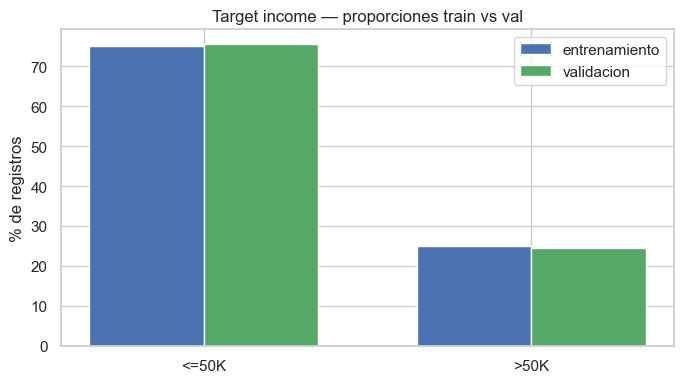

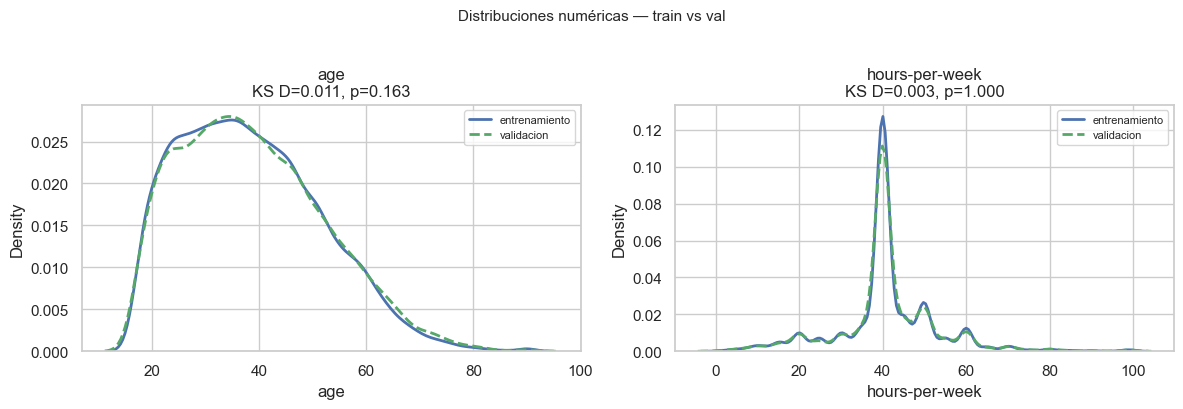

Prueba KS (numéricas):


,variable,estadistico_ks,p_valor
0,age,0.0112,0.1625
1,hours-per-week,0.0027,1.0000



Máxima diferencia de proporción por categoría (puntos porcentuales):


,variable,max_diff_pp
0,education,0.75
1,workclass,0.71
2,native-country,0.37


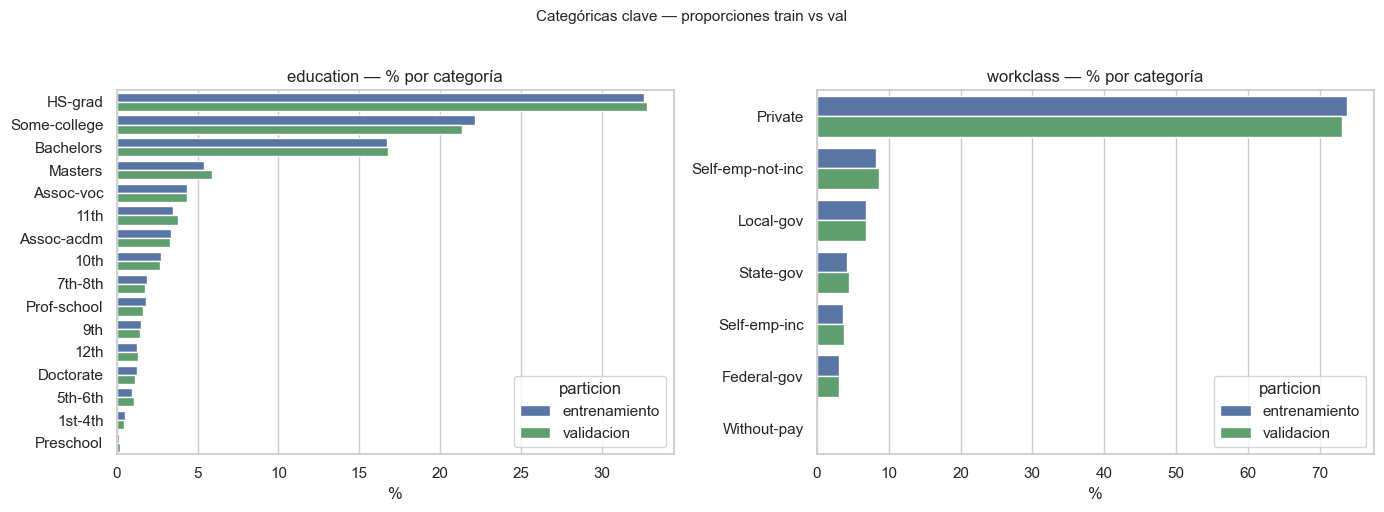

In [126]:
# 2.9 — Comparación de distribuciones train vs val
from scipy import stats

ORDEN_CLASES_OBJETIVO = ["<=50K", ">50K"]
COLUMNAS_NUMERICAS_SHIFT = ["age", "hours-per-week"]
COLUMNAS_CATEGORICAS_SHIFT = ["education", "workclass"]

print("=== 2.9 — Train vs val: target y features clave ===\n")


def proporciones_target(df: pd.DataFrame) -> pd.Series:
    return (
        df[COLUMNA_OBJETIVO]
        .value_counts(normalize=True)
        .reindex(ORDEN_CLASES_OBJETIVO)
        .mul(100)
        .round(2)
    )


prop_entrenamiento = proporciones_target(df_entrenamiento)
prop_validacion = proporciones_target(df_validacion)

df_comparacion_target = pd.DataFrame(
    {
        "clase": ORDEN_CLASES_OBJETIVO,
        "pct_entrenamiento": prop_entrenamiento.values,
        "pct_validacion": prop_validacion.values,
    }
)
df_comparacion_target["diff_pp"] = (
    df_comparacion_target["pct_validacion"] - df_comparacion_target["pct_entrenamiento"]
).round(2)

display(df_comparacion_target)

tabla_chi = pd.DataFrame(
    {
        "entrenamiento": df_entrenamiento[COLUMNA_OBJETIVO].value_counts(),
        "validacion": df_validacion[COLUMNA_OBJETIVO].value_counts(),
    }
).fillna(0)
_, p_chi_target, _, _ = stats.chi2_contingency(tabla_chi)
print(f"Chi-cuadrado target (train vs val): p = {p_chi_target:.4f}\n")

# --- Gráfico: target ---
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(ORDEN_CLASES_OBJETIVO))
ancho = 0.35
ax.bar(x - ancho / 2, prop_entrenamiento.values, width=ancho, label="entrenamiento", color="#4C72B0")
ax.bar(x + ancho / 2, prop_validacion.values, width=ancho, label="validacion", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(ORDEN_CLASES_OBJETIVO)
ax.set_ylabel("% de registros")
ax.set_title("Target income — proporciones train vs val")
ax.legend()
plt.tight_layout()
plt.show()

# --- Numéricas: KDE superpuesta ---
filas_ks = []
fig, axes = plt.subplots(1, len(COLUMNAS_NUMERICAS_SHIFT), figsize=(12, 4))
if len(COLUMNAS_NUMERICAS_SHIFT) == 1:
    axes = [axes]

for ax, columna in zip(axes, COLUMNAS_NUMERICAS_SHIFT):
    sns.kdeplot(df_entrenamiento[columna], ax=ax, label="entrenamiento", color="#4C72B0", linewidth=2)
    sns.kdeplot(df_validacion[columna], ax=ax, label="validacion", color="#55A868", linewidth=2, linestyle="--")
    estadistico_ks, p_valor = stats.ks_2samp(df_entrenamiento[columna], df_validacion[columna])
    filas_ks.append(
        {
            "variable": columna,
            "estadistico_ks": round(estadistico_ks, 4),
            "p_valor": round(p_valor, 4),
        }
    )
    ax.set_title(f"{columna}\nKS D={estadistico_ks:.3f}, p={p_valor:.3f}")
    ax.set_xlabel(columna)
    ax.legend(fontsize=8)

fig.suptitle("Distribuciones numéricas — train vs val", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

df_prueba_ks = pd.DataFrame(filas_ks)
print("Prueba KS (numéricas):")
display(df_prueba_ks)

# --- Categóricas: máxima diferencia de proporción ---
COLUMNAS_TABLA_CATEGORICAS = COLUMNAS_CATEGORICAS_SHIFT + ["native-country"]
filas_cat = []
for columna in COLUMNAS_TABLA_CATEGORICAS:
    pct_ent = df_entrenamiento[columna].value_counts(normalize=True)
    pct_val = df_validacion[columna].value_counts(normalize=True)
    categorias = pct_ent.index.union(pct_val.index)
    diffs = [abs(pct_ent.get(cat, 0) - pct_val.get(cat, 0)) for cat in categorias]
    max_diff_pp = 100 * max(diffs)
    filas_cat.append({"variable": columna, "max_diff_pp": round(max_diff_pp, 2)})

print("\nMáxima diferencia de proporción por categoría (puntos porcentuales):")
display(pd.DataFrame(filas_cat))

fig, axes = plt.subplots(1, len(COLUMNAS_CATEGORICAS_SHIFT), figsize=(14, 5))
if len(COLUMNAS_CATEGORICAS_SHIFT) == 1:
    axes = [axes]

for ax, columna in zip(axes, COLUMNAS_CATEGORICAS_SHIFT):
    pct_ent = df_entrenamiento[columna].value_counts(normalize=True).mul(100)
    pct_val = df_validacion[columna].value_counts(normalize=True).mul(100)
    categorias = pct_ent.index.union(pct_val.index)
    orden = pct_ent.reindex(categorias).fillna(0).sort_values(ascending=False).index

    df_grafico = pd.DataFrame(
        {
            "categoria": list(orden),
            "entrenamiento": [pct_ent.get(c, 0) for c in orden],
            "validacion": [pct_val.get(c, 0) for c in orden],
        }
    )
    df_largo = df_grafico.melt(id_vars="categoria", var_name="particion", value_name="porcentaje")

    sns.barplot(
        data=df_largo,
        y="categoria",
        x="porcentaje",
        hue="particion",
        order=list(orden),
        ax=ax,
        palette={"entrenamiento": "#4C72B0", "validacion": "#55A868"},
    )
    ax.set_title(f"{columna} — % por categoría")
    ax.set_xlabel("%")
    ax.set_ylabel("")

fig.suptitle("Categóricas clave — proporciones train vs val", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


#### 2.10 — Hallazgos de calidad y consistencia (impacto en el preprocesado)

Síntesis de lo observado en las Fases 0–2 y en los ítems **2.8** y **2.9**. Sirve de insumo directo para definir transformaciones en la **Fase 3**.

---

**1. Calidad general del dataset**

- **Sin valores faltantes** detectados con los marcadores revisados (`?`, cadenas vacías, etc.) en train ni val.
- **Sin filas duplicadas** en ninguno de los dos splits.
- **Esquema coherente:** mismas 14 columnas en train y val; 13 predictores + target `income`.
- **Typos / nombres raros en categorías del dataset** (no corregir el CSV; mapear en preprocesado si hace falta): p. ej. `Holand-Netherlands`, `Trinadad&Tobago` en `native-country`. Son pocos casos y no bloquean el análisis.

---

**2. Variable objetivo (`income`)**

- **Desbalance moderado:** ~75% `<=50K`, ~25% `>50K` en train (proporciones muy similares en val).
- **Implicancia:** usar **F1 macro**, matriz de confusión y métricas de la clase minoritaria; no confiar solo en accuracy. Evaluar **pesos de clase** o umbral si la minoritaria queda mal clasificada.

---

**3. Variables numéricas**

| Variable | Hallazgo | Preprocesado sugerido |
|----------|----------|------------------------|
| `age` | Distribución aprox. unimodal; relación leve con `hours-per-week` | Escalado estándar (p. ej. StandardScaler) |
| `hours-per-week` | Rango acotado, sin inflación extrema en cero | Escalado estándar |
| `capital-gain` | ~92% en cero; cola larga en positivos | Tratar 0 aparte o `log1p` en valores > 0; escalado robusto |
| `capital-loss` | ~95% en cero; patrón similar a `capital-gain` | Igual que `capital-gain` |

- **Correlaciones entre numéricas:** todas **débiles**; no hay redundancia fuerte que obligue a eliminar features.

---

**4. Variables categóricas**

**Cardinalidad (criterio TP: alta si ≥ 10 valores únicos):**

| Tipo | Variables |
|------|-----------|
| **Alta** | `education`, `occupation`, `native-country`, `skill-profile` |
| **Baja** | `workclass`, `marital-status`, `relationship`, `race`, `sex` |

**Señal respecto del target (train):**

- Fuerte asociación con `>50K` en `education` (niveles altos), `marital-status`, `sex`, `occupation` y algunas categorías de `workclass`.
- `native-country` y `skill-profile`: dominancia de pocas categorías (`United-States`, perfiles frecuentes); tasas inestables en categorías con pocos casos.

**Categorías raras (train < 50 registros; ítem 2.8):**

- **Ninguna categoría solo en val** (split coherente).
- **`Holand-Netherlands`** en `native-country`: 1 registro solo en train.
- **Mayor problema de rarezas:** `native-country` (~21 categorías raras), luego `skill-profile` (~5); el resto: 0–1 rara por variable.

**Implicancia categóricas:**

- **Alta cardinalidad** (`native-country`, `skill-profile`): agrupar categorías poco frecuentes en `Otra` / `Desconocido`; candidatas a **embedding** en (b) y decisión explícita en (c).
- **`education`:** orden natural → **encoding ordinal** razonable además de otras opciones.
- **Baja cardinalidad** (`sex`, `race`, `relationship`, etc.): **mantener** categorías; **one-hot** viable en (c).
- Definir política de **categoría no vista** en val/producción (`Desconocido` / `Otra`).

---

**5. Consistencia train / val (ítem 2.9)**

- **Sin data shift evidente:** proporciones del target y de features clave casi iguales; pruebas KS y diferencias máximas por categoría < ~1 pp.
- **Implicancia:** no hace falta re-balancear o estratificar val de forma especial por shift; el esfuerzo de preprocesado va en **transformaciones por tipo de variable**, no en “igualar” splits.

---

**6. Prioridades para la Fase 3 (tabla de transformaciones)**

1. Numéricas: escalado; tratamiento especial de `capital-gain` y `capital-loss`.
2. Categóricas de alta cardinalidad: agrupar rarezas + embedding (b) / one-hot selectivo (c).
3. `education`: aprovechar orden ordinal donde corresponda.
4. Target: codificación binaria para la red; métricas que contemplen desbalance.
5. Vocabulario y mapeos **ajustados solo con train**; misma política de `Desconocido` / `Otra` en val.

---

*Con esto se cierra la **Fase 2** del EDA. La **Fase 3** define la transformación concreta variable por variable.*

### Fase 3 — Criterios para elegir transformación (por variable)

A partir del EDA (Fases 0–2, cierre en **2.10**), evaluamos **cada** predictor para decidir cómo entrará al modelo en **(b)** y **(c)**. No se implementa el pipeline aquí; solo se fijan criterios y decisiones.

---

#### 3.1 — Cardinalidad

**Criterio del TP:** variable categórica con **≥ 10 valores únicos** → **alta cardinalidad** (candidata a **embedding** u otra estrategia que no multiplique demasiado la dimensión de entrada). Por debajo de 10 → **baja cardinalidad** (one-hot suele ser manejable).

**Fuente en el notebook:** conteos en train, celda **1.5** (`df_cardinalidad`, umbral `UMBRAL_ALTA_CARDINALIDAD = 10`). Inventario detallado en **2.4**; rarezas en **2.8**.

| Variable | Tipo | Valores únicos (train) | Clasificación | Implicancia para la codificación |
|----------|------|------------------------|---------------|--------------------------------|
| `age` | numérica | 72 | — | No aplica criterio categórico: es variable continua/discreta; se **escala**, no se one-hot. |
| `capital-gain` | numérica | 118 | — | Idem; además inflación en cero (**1.7**). |
| `capital-loss` | numérica | 90 | — | Idem. |
| `hours-per-week` | numérica | 94 | — | Idem. |
| `workclass` | categórica | 7 | **Baja** | One-hot añade pocas columnas (7); embedding opcional pero no necesario por cardinalidad. |
| `marital-status` | categórica | 7 | **Baja** | One-hot viable (7). |
| `relationship` | categórica | 6 | **Baja** | One-hot viable (6). |
| `race` | categórica | 5 | **Baja** | One-hot viable (5). |
| `sex` | categórica | 2 | **Baja** | One-hot mínimo (2); también puede codificarse con un solo bit. |
| `education` | categórica | 16 | **Alta** | One-hot generaría 16 columnas; mejor **ordinal** (orden natural, celda **1.6**) o **embedding** en (b). |
| `occupation` | categórica | 14 | **Alta** | One-hot = 14 columnas; razonable **embedding** en (b); en (c) one-hot aún es posible pero pesado si se suman muchas categóricas. |
| `native-country` | categórica | 41 | **Alta** | One-hot = 41 columnas + muchas categorías raras (**2.8**); priorizar **agrupar rarezas** (`Otra`) y **embedding** en (b). |
| `skill-profile` | categórica | 80 | **Alta** | La cardinalidad más alta; one-hot = 80 columnas → poco práctico. **Embedding** casi obligado en (b); en (c) exige mucho ancho de entrada si se one-hot-ea todo. |

**Resumen por grupo**

- **Categóricas de alta cardinalidad (4):** `education`, `occupation`, `native-country`, `skill-profile`. Son las que **más justifican embedding** en (b) o, en (c), one-hot solo si se acepta un vector de entrada muy ancho (o se agrupan categorías antes).
- **Categóricas de baja cardinalidad (5):** `workclass`, `marital-status`, `relationship`, `race`, `sex`. Encajan bien con **one-hot** en (c); en (b) pueden ir con embedding de dimensión pequeña o one-hot según el diseño final de la red.
- **Numéricas (4):** el número de valores distintos es alto, pero **no implica** alta cardinalidad en sentido categórico: no se expanden a columnas dummy. El tratamiento es **escalado** y, en `capital-*`, transformación por ceros/cola (**2.10**).

**Nota sobre agrupación:** en `native-country` y `skill-profile`, aun con embedding conviene **reducir rarezas** antes de entrenar (ítem **2.8**), para no desperdiciar parámetros en categorías con 1–20 ejemplos.

*Siguiente paso:* **3.2** — contexto semántico (nominal vs ordinal) de cada categórica.

#### 3.2 — Contexto semántico (nominal vs ordinal)

**¿Qué evaluamos?** Si las categorías tienen un **orden con sentido** (ordinal) o son **etiquetas sin jerarquía** (nominal). Eso condiciona si tiene sentido un **label/ordinal encoding** (un solo entero con orden) o conviene **one-hot / embedding** sin imponer distancias falsas entre categorías.

**Fuentes en el notebook:** orden explícito de `education` en celda **1.6** (`ORDEN_EDUCACION`); resto de categóricas en **1.6b**, **2.4** y **2.7**.

| Variable | Naturaleza | ¿Orden natural? | Comentario | Codificación coherente con el significado |
|----------|------------|-----------------|------------|-------------------------------------------|
| `education` | **Ordinal** | **Sí** | Niveles educativos de menor a mayor (`Preschool` → `Doctorate`; ver gráfico ordinal en **1.6**). | **Ordinal encoding** (enteros 0…K−1 siguiendo `ORDEN_EDUCACION`) o **embedding** en (b) que aprenda el orden; one-hot también es válido pero no explota el orden. |
| `marital-status` | **Nominal** | No estricto | Estados civiles sin una escala única (p. ej. `Divorced` vs `Separated` no son “más” o “menos” que `Married`). | **One-hot** en (c); en (b) **embedding** o one-hot. Evitar ordinal arbitrario. |
| `relationship` | **Nominal** | No | Roles frente al jefe de hogar (`Husband`, `Wife`, `Own-child`, …) sin orden lineal. | **One-hot** o **embedding**; no ordinal. |
| `workclass` | **Nominal** | No | Tipos de empleador (`Private`, `Self-emp-not-inc`, `Federal-gov`, …) sin jerarquía. | **One-hot** (baja cardinalidad, **3.1**) o embedding pequeño en (b). |
| `occupation` | **Nominal** | No | Oficios/áreas laborales; no hay nivel “mayor” universal entre `Tech-support` y `Farming-fishing`. | **Embedding** preferible en (b) por cardinalidad; one-hot posible en (c) con 14 columnas. |
| `race` | **Nominal** | No | Autoidentificación racial; **no** debe codificarse con orden numérico que implique jerarquía. | **One-hot** o **embedding** sin orden fijo; nunca ordinal. |
| `sex` | **Nominal** | No | Dos categorías (`Male`, `Female`) sin orden; binaria pero **nominal** en sentido estadístico. | Un bit, one-hot (2 cols) o embedding dim. 2; evitar tratar `Female` como “1” y `Male` como “0” con significado de magnitud. |
| `native-country` | **Nominal** | No | Países; no hay orden natural (salvo agrupaciones geográficas que **no** están en el dataset). | Tras agrupar rarezas (**2.8**): **embedding** en (b); one-hot solo si se reduce mucho el número de países. |
| `skill-profile` | **Nominal** | No | Perfiles técnicos heterogéneos; nombres no definen un nivel único ordenable. | **Embedding** en (b); agrupar rarezas antes; one-hot poco práctico (80 categorías, **3.1**). |

**Variables numéricas (`age`, `capital-gain`, `capital-loss`, `hours-per-week`)**

No entran en nominal/ordinal: son **cuantitativas**. El “orden” es el de los números reales; el preprocesado es **escalado** y transformaciones de forma (**1.7**, **2.10**), no codificación categórica.

**Resumen**

- **Única ordinal clara:** `education` → aprovechar orden en (a)/(b) si se usa label/ordinal; en (b) el embedding puede aprenderlo sin fijar enteros.
- **Resto de categóricas: nominales** → no asignar enteros 1, 2, 3… por orden alfabético o por frecuencia; eso introduciría una falsa métrica de distancia.
- **Coherencia con 3.1:** las nominales de **alta cardinalidad** siguen priorizando **embedding**; las de **baja** siguen siendo cómodas en **one-hot** en (c).

*Siguiente paso:* **3.3** — relación con el target (señal predictiva; celda **2.7**).

#### 3.3 — Relación con el target (`income`)

**¿Qué evaluamos?** Si cada variable **separa** las clases `<=50K` y `>50K` en train. Una señal fuerte sugiere que la feature aportará al modelo; una señal débil no implica descartarla, pero habrá que combinarla con otras.

**Fuentes en el notebook:** gráficos y tabla resumen en **2.7** (% `>50K` por categoría, conteo mínimo 50); boxplots numéricas vs `income` en **1.4**; desbalance global del target en **1.3**.

*Criterio informal de intensidad (train):* comparación de extremos por variable (categoría con mayor vs menor % `>50K`, con conteo ≥ 50; o medias numéricas por clase). **Fuerte** ≈ separación clara y amplia; **moderada** ≈ diferencias visibles pero menos extremas; **débil** ≈ perfiles muy parecidos entre clases.

---

**Categóricas** (celda **2.7**)

| Variable | Intensidad de señal | Evidencia (train) | Comentario |
|----------|---------------------|-------------------|------------|
| `education` | **Fuerte** | `Prof-school` ~75% `>50K` vs `1st-4th` ~4% (spread ~71 pp) | Muy discriminativa; coherente con orden ordinal (**3.2**). |
| `occupation` | **Fuerte** | `Exec-managerial` ~49% vs `Priv-house-serv` ~1% (spread ~48 pp) | Alta separación entre oficios. |
| `relationship` | **Fuerte** | `Wife` ~49% vs `Own-child` ~1% (spread ~48 pp) | Refleja en parte composición del hogar e ingreso. |
| `marital-status` | **Fuerte** | `Married-civ-spouse` ~46% vs `Never-married` ~5% (spread ~41 pp) | Patrón muy marcado en el dataset. |
| `workclass` | **Fuerte** | `Self-emp-inc` ~56% vs `Private` ~22% (spread ~34 pp) | Tipos de empleo con ingresos distintos. |
| `sex` | **Fuerte** | `Male` ~31% vs `Female` ~11% (spread ~20 pp) | Diferencia clara; interpretar con cautela social, no causal. |
| `skill-profile` | **Fuerte** (inestable) | Perfiles punta hasta ~93% `>50K` vs ~3% en perfiles básicos (spread muy alto) | Muchas categorías raras (**2.8**): tasas extremas en celdas con pocos casos; señal real pero ruidosa. |
| `native-country` | **Moderada a fuerte** | `India` ~40% vs algunos países ~3% (spread ~37 pp); domina `United-States` (~91% filas) | Separación entre países, pero la mayoría de filas es un solo país; rarezas poco fiables. |
| `race` | **Moderada** | `Asian-Pac-Islander` ~28% vs `Other` ~9% (spread ~19 pp) | Menor contraste que `sex` o `education`. |

---

**Numéricas** (celda **1.4**, medias en train)

| Variable | Intensidad de señal | Evidencia (train) | Comentario |
|----------|---------------------|-------------------|------------|
| `capital-gain` | **Fuerte** | Media ~149 (`<=50K`) vs ~3938 (`>50K`); mediana `>50K` >> mediana `<=50K` en boxplot | Muchos ceros, pero los positivos separan clases (**1.7**). |
| `capital-loss` | **Moderada** | Media ~53 vs ~194; patrón similar a `capital-gain` con más ceros | Aporta, con menor contraste que `capital-gain`. |
| `age` | **Moderada** | Media ~37 (`<=50K`) vs ~44 (`>50K`) | Diferencia sistemática pero solapamiento amplio en boxplots. |
| `hours-per-week` | **Moderada / débil** | Media ~39 vs ~46 | Relación leve; útil como contexto laboral, no como único predictor. |

---

**Resumen e implicancias**

- **Mayor señal predictiva aparente:** `education`, `occupation`, `relationship`, `marital-status`, `workclass`, `sex`, `capital-gain` y (con reservas) `skill-profile`.
- **Señal moderada:** `age`, `hours-per-week`, `capital-loss`, `race`, `native-country`.
- **Ninguna variable “sobra” por sí sola:** incluso las débiles pueden combinar no linealmente en la red; las fuertes justifican priorizarlas en el diseño (p. ej. no agrupar de más categorías con buena separación).
- **Coherencia con 3.1–3.2:** las categóricas fuertes y de alta cardinalidad (`education`, `occupation`, `skill-profile`) siguen siendo buenas candidatas a **embedding** en (b); las de baja cardinalidad y buena señal (`sex`, `marital-status`) funcionan bien con **one-hot** en (c).
- **Recordatorio:** correlación/asociación en el EDA **no implica causalidad**; solo orienta el preprocesado y la expectativa de importancia.

*Siguiente paso:* **3.4** — estabilidad train/val (celdas **2.8** y **2.9**).

#### 3.4 — Estabilidad train / val

**¿Qué evaluamos?** Si las **mismas categorías y rangos** aparecen en train y val, y si las proporciones son parecidas. Problemas típicos: categoría **solo en val** (no vista al entrenar), **solo en train** (no se evalúa en val), o **data shift** fuerte entre splits.

**Fuentes en el notebook:** cobertura de categorías y rarezas en **2.8**; comparación de distribuciones en **2.9**; proporciones del target en **1.3**.

---

**1. Target `income`**

| Aspecto | Train | Val | ¿Estable? |
|---------|-------|-----|-----------|
| % `<=50K` | ~75,1% | ~75,4% | **Sí** (diff < 0,4 pp) |
| % `>50K` | ~24,9% | ~24,6% | **Sí** |

Chi-cuadrado train vs val: **p ≈ 0,46** (**2.9**) → no hay evidencia de desbalance distinto entre splits.

---

**2. Categorías: presencia y rarezas (celda 2.8)**

| Hallazgo | Detalle | Implicancia |
|----------|---------|-------------|
| **Solo en val** | **0** categorías en ninguna variable | No hace falta una política urgente de `Desconocido` por “nunca visto en train” en val; aun así conviene definirla para producción. |
| **Solo en train** | 1 caso: `Holand-Netherlands` en `native-country` (1 registro) | Impacto despreciable en métricas de val. |
| **Raras en train (< 50 filas)** | `native-country` ~21; `skill-profile` ~5; 0–1 en el resto | Mapeos y vocabulario deben construirse con **train**; rarezas agrupadas en `Otra` / `Desconocido`. |
| **Cobertura general** | Todas las categorías de val existen en train (salvo el typo anterior) | El split es **coherente** para validar codificaciones. |

---

**3. Distribuciones train vs val (celda 2.9)**

| Tipo | Resultado | ¿Estable? |
|------|-----------|-----------|
| Numéricas (`age`, `hours-per-week`) | KS: **p > 0,05** (sin diferencia significativa) | **Sí** |
| Categóricas (`education`, `workclass`, `native-country`) | Diferencia máxima de proporción **< ~1 pp** por categoría | **Sí** |
| **Data shift global** | No observado | Val sirve para estimar generalización sin “corregir” el split |

---

**4. Por variable (síntesis)**

| Variable | Estabilidad train/val | Nota |
|----------|----------------------|------|
| Todas las categóricas (cobertura) | **Alta** | Sin categorías exclusivas de val. |
| `native-country`, `skill-profile` | **Alta** (con rarezas) | Estables en proporciones globales; muchas categorías con poco soporte en **ambos** splits. |
| `education`, `occupation`, `workclass`, etc. | **Alta** | Proporciones casi iguales entre splits. |
| Numéricas | **Alta** | Sin shift evidente en las revisadas. |
| Target | **Alta** | Mismo perfil de clases. |

---

**Resumen e implicancias para el preprocesado**

- **Vocabulario y mapeos:** ajustar **solo con train**; aplicar la misma transformación a val (sin re-aprender categorías desde val).
- **Categoría no vista:** en este dataset val no fuerza el caso, pero en (b)/(c) conviene reservar índice o bucket **`Desconocido` / `Otra`** por si en inferencia aparece un valor nuevo.
- **No re-balancear ni re-estratificar val** por shift: el problema no está en el split, sino en **cardinalidad, rarezas y tipo de encoding** (**3.1–3.3**).
- **Agrupación de rarezas:** prioritaria en `native-country` y `skill-profile` (**2.8**), no por inestabilidad train/val sino por **pocos ejemplos** en train.

*Siguiente paso:* **3.5** — elegir transformación concreta por variable (síntesis de 3.1–3.4 y tabla final en Fase 4).

#### 3.5 — Transformación elegida por variable

Decisión integrando **3.1** (cardinalidad), **3.2** (semántica), **3.3** (señal vs target) y **3.4** (estabilidad train/val). Esta tabla es también el **entregable de la Fase 4** (ítems **4.1–4.4**); ver celda siguiente.

**Reglas transversales (train → val)**

1. Ajustar vocabularios, umbrales de agrupación y escaladores **solo con train**; transformar val con los mismos objetos.
2. En `native-country` y `skill-profile`: **top-N por frecuencia + bucket `Otra`** para categorías raras (**2.8**); reservar **`Desconocido`** para valores no vistos en inferencia.
3. Target `income`: codificación binaria `<=50K` → 0, `>50K` → 1 (para BCE).

**Variedad de codificaciones (requisito del TP):** usamos **escalado** (numéricas), **ordinal** (`education`), **one-hot** (categóricas baja cardinalidad en ambos modelos) y **embedding** (categóricas alta cardinalidad en **(b)**; en **(c)** esas mismas pasan a one-hot).

---

| Variable | Tipo | Card. | Transformación en **(b)** embeddings | Transformación en **(c)** sin embeddings | Dim. embedding (b) | Fundamento breve |
|----------|------|-------|--------------------------------------|------------------------------------------|--------------------|------------------|
| `income` | target | 2 | Label 0/1 | Label 0/1 | — | Clasificación binaria. |
| `age` | numérica | 72* | `StandardScaler` | `StandardScaler` | — | Continua acotada; señal moderada (**3.3**). |
| `hours-per-week` | numérica | 94* | `StandardScaler` | `StandardScaler` | — | Igual que `age`. |
| `capital-gain` | numérica | 118* | Indicador `>0` + `log1p` en positivos + `StandardScaler` | Igual | — | Inflación en cero (**1.7**); fuerte señal (**3.3**). |
| `capital-loss` | numérica | 90* | Igual que `capital-gain` | Igual | — | Mismo patrón que `capital-gain`. |
| `education` | categórica | 16 (alta) | **Ordinal** (`ORDEN_EDUCACION`, **1.6**) | **One-hot** (16 columnas) | — | Única ordinal clara (**3.2**); alta señal; en (b) no hace falta embedding si explotamos el orden. |
| `occupation` | categórica | 14 (alta) | **Embedding** | **One-hot** (14) | **8** | Nominal, alta señal; dim ≈ min(8, ⌊√14⌋+2). |
| `native-country` | categórica | 41 (alta) | **Top-12 + `Otra`** → **Embedding** | **One-hot** (~13) | **12** | Muchas rarezas (**2.8**); agrupar antes; dim moderada tras reducir categorías. |
| `skill-profile` | categórica | 80 (alta) | **Top-15 + `Otra`** → **Embedding** | **One-hot** (~16) | **12** | Cardinalidad máxima; misma política que país; señal fuerte pero ruidosa (**3.3**). |
| `workclass` | categórica | 7 (baja) | **One-hot** (7) | **One-hot** (7) | — | Baja cardinalidad; nominal; buena señal. |
| `marital-status` | categórica | 7 (baja) | **One-hot** (7) | **One-hot** (7) | — | Idem. |
| `relationship` | categórica | 6 (baja) | **One-hot** (6) | **One-hot** (6) | — | Idem. |
| `race` | categórica | 5 (baja) | **One-hot** (5) | **One-hot** (5) | — | Nominal; sin orden (**3.2**). |
| `sex` | categórica | 2 (baja) | **One-hot** (2) | **One-hot** (2) | — | Dos categorías; fuerte señal (**3.3**). |

*\*En numéricas, “cardinalidad” = valores distintos; no implica one-hot (**3.1**).*

---

**Embeddings en (b) — resumen**

| Variable | Categorías tras agrupación (aprox.) | Dim. elegida | Criterio preliminar |
|----------|-------------------------------------|--------------|---------------------|
| `occupation` | 14 | 8 | Entre 4 y 8; balance capacidad / sobreajuste. |
| `native-country` | ~13 (top-12 + `Otra`) | 12 | Tras agrupar rarezas; más dim. que `occupation` por heterogeneidad. |
| `skill-profile` | ~16 (top-15 + `Otra`) | 12 | Similar a país; muchas categorías originales colapsadas. |

En **(b)** no usamos capa de embedding para `education` porque el **ordinal** ya transmite orden con un solo feature escalado (o normalizado 0–1). Las categóricas de **baja cardinalidad** entran por **one-hot** concatenado al vector de numéricas + ordinal + embeddings.

**One-hot en (c) — resumen**

Todas las categóricas que en **(b)** iban a **embedding** (`occupation`, `native-country`, `skill-profile`) pasan a **one-hot** en **(c)**, según el enunciado. `education` también es one-hot (en (b) fue ordinal). Ancho de entrada mayor que en (b); misma arquitectura densa salvo dropout (**consigna c**).

---

**Chequeo frente a criterios 3.1–3.4**

| Criterio | ¿Cumplido? |
|----------|------------|
| 3.1 Alta card. → no one-hot completo sin agrupar | Sí: agrupación + embedding en (b); one-hot acotado en (c). |
| 3.2 Ordinal solo donde corresponde | Sí: solo `education`. |
| 3.3 Priorizar variables con señal | Sí: todas las fuertes incluidas; numéricas con tratamiento especial en `capital-*`. |
| 3.4 Vocabulario desde train + `Desconocido` | Sí: estable en val; política definida por precaución. |

---

*Con esto cierra la **Fase 3**. Las decisiones finales por variable están en la tabla de arriba; la **Fase 4** las referencia sin duplicarlas.*

### Fase 4 — Tabla de decisiones finales

Los ítems **4.1–4.4** no repiten una tabla nueva: la **tabla de transformaciones por variable** ya está definida en la celda **3.5** (columnas *Transformación en (b)/(c)*, *Dim. embedding* y *Fundamento breve* cubren *transformación elegida*, *justificación* y *uso en modelos*).

**4.1 — Tabla por variable** → ver **3.5** (tabla principal + resúmenes de embedding y one-hot).

**4.2 — Variedad de codificaciones** → cumplido en **3.5**: **escalado** (numéricas), **ordinal** (`education`), **one-hot** (categóricas baja cardinalidad) y **embedding** (alta cardinalidad en **(b)**).

**4.3 — Embedding en (b) vs one-hot en (c)** → en **3.5**: embedding para `occupation`, `native-country`, `skill-profile` en **(b)**; esas tres + `education` (ordinal en b) pasan a **one-hot** en **(c)** según el enunciado.

**4.4 — Numéricas** → en **3.5**: `StandardScaler` en `age` y `hours-per-week`; indicador `>0` + `log1p` + escalado en `capital-gain` y `capital-loss` (justificado en **1.7**, **2.10**, **3.3**).

*Siguiente paso:* **5.1** — síntesis del EDA (celda **Fase 5**).

### Fase 5 — Cierre de la consigna (a)

#### 5.1 — Síntesis del EDA

El dataset **Adult Census Income** (train ~30 k filas, val ~7,5 k) está **limpio** en cuanto a faltantes y duplicados, con **train y val alineados** (mismo esquema, proporciones de `income` similares ~75% `<=50K` / ~25% `>50K`, sin data shift evidente en **2.9**). El target está **moderadamente desbalanceado**, por lo que conviene priorizar **F1 macro** y el desempeño en la clase `>50K`, no solo accuracy.

En **variables numéricas**, `capital-gain` y `capital-loss` muestran **inflación en cero** y colas largas (**1.7**); `capital-gain` además separa bien las clases (**1.4**, **3.3**). `age` y `hours-per-week` aportan señal más moderada; las cuatro numéricas están **poco correlacionadas** entre sí (**2.3**).

En **categóricas**, hay **cuatro de alta cardinalidad** (≥ 10: `education`, `occupation`, `native-country`, `skill-profile`) y cinco de baja. Varias variables discriminan fuerte el ingreso alto — p. ej. `education`, `marital-status`, `sex`, `occupation` (**2.7**) — mientras `native-country` y `skill-profile` concentran **muchas categorías raras** (**2.8**), lo que obliga a **agrupar en `Otra`** y a usar **embeddings** en (b) o **one-hot acotado** en (c).

Con base en este EDA, las **transformaciones elegidas** (tabla en **3.5**, referenciada en **Fase 4**) combinan **escalado**, **ordinal** (`education`), **one-hot** (baja cardinalidad) y **embedding** (alta cardinalidad en b), con vocabulario ajustado **solo en train** y bucket **`Desconocido` / `Otra`** para rarezas y valores nuevos. Con esto queda cerrado el análisis exploratorio y el criterio de preprocesado para las consignas **(b)** y **(c)**.

**5.2 — Salidas guardadas:** pendiente de verificación manual (`Run all` y revisar gráficos/prints antes de entregar).

**5.3 — Checklist del enunciado (a):** pendiente de verificación manual (confirmar que todo lo pedido está respondido debajo de `## a)` y antes de `## b)`).

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.